# What this notebook is doing (water year precip comparison)

This notebook compares water-year precipitation totals across the datasets I have been using for Skagit.
The main setup here is the 3-region split: Upper Skagit, Sauk, and Lower Skagit.

It computes water-year totals by dataset and region, then saves the comparison tables and plots.
A few later cells also make a single basin-wide water-year graph by averaging across the three sub-basins, mostly as a simpler summary view.

There are older and newer versions of the workflow still kept in this notebook, but the later cells are the more updated versions after the ORNL/UCLA fixes and the HRRR updates.


[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09'] -> skipping WY2014
[HRRR] WY2015: missing months ['2014-10', '2014-11'] -> skipping WY2015
[HRRR] WY2016: Upper Skagit=1630.6, Sauk=1782.7, Lower Skagit=1633.6
[HRRR] WY2017: Upper Skagit=1363.2, Sauk=1587.0, Lower Skagit=1579.0
[HRRR] WY2018: Upper Skagit=1645.3, Sauk=2002.6, Lower Skagit=1925.2
[HRRR] WY2019: Upper Skagit=1597.5, Sauk=1671.6, Lower Skagit=1442.2
[HRRR] WY2020: Upper Skagit=1693.6, Sauk=2136.6, Lower Skagit=1744.2
[HRRR] WY2021: Upper Skagit=1567.2, Sauk=2014.1, Lower Skagit=1516.4
[HRRR] WY2022: Upper Skagit=1628.3, Sauk=2109.2, Lower Skagit=1774.7
[HRRR] WY2023: Upper Skagit=1056.3, Sauk=1345.8, Lower Skagit=1271.2
[HRRR] WY2024: Upper Skagit=964.2, Sauk=1306.6, Lower Skagit=1186.7
[ERA5] Opening gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1

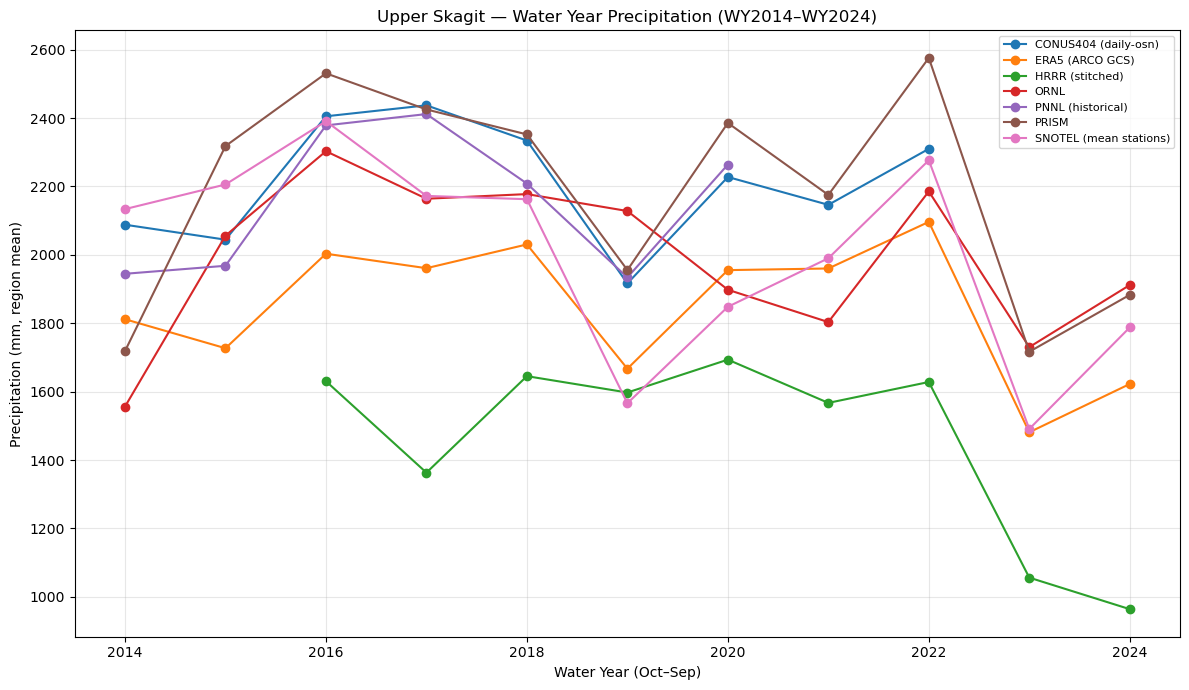

Saved plot → /data0/balaji24/data/derived/water_year_precip_Sauk_2014_2024.png


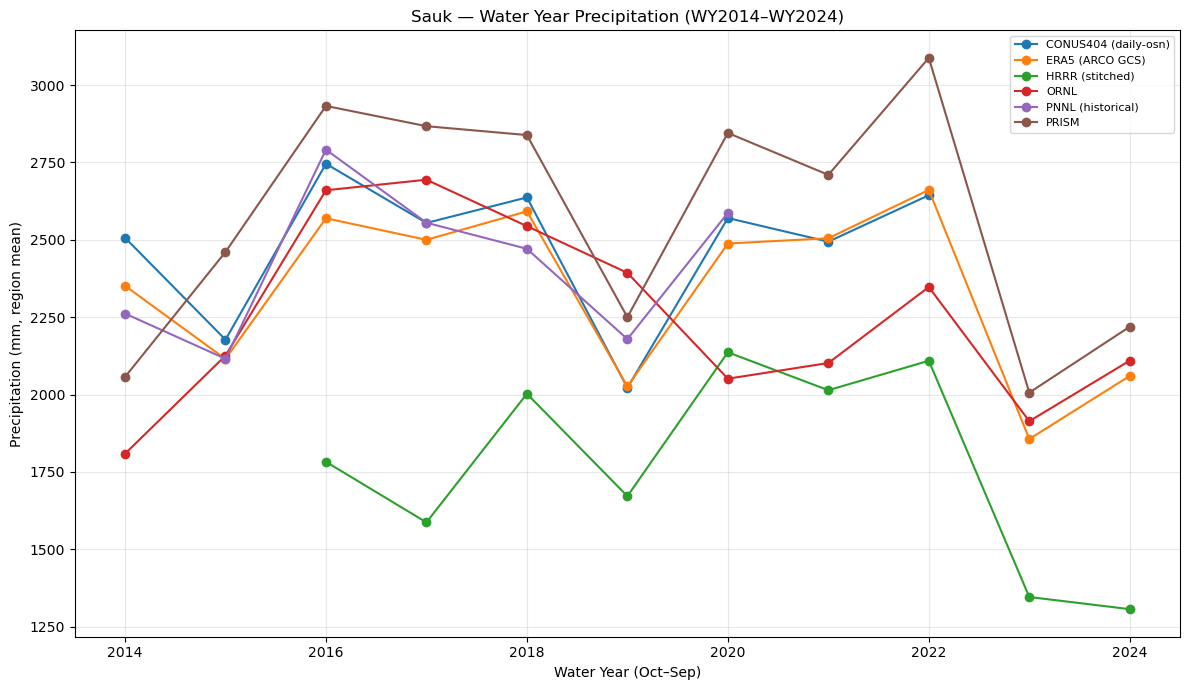

Saved plot → /data0/balaji24/data/derived/water_year_precip_Lower_Skagit_2014_2024.png


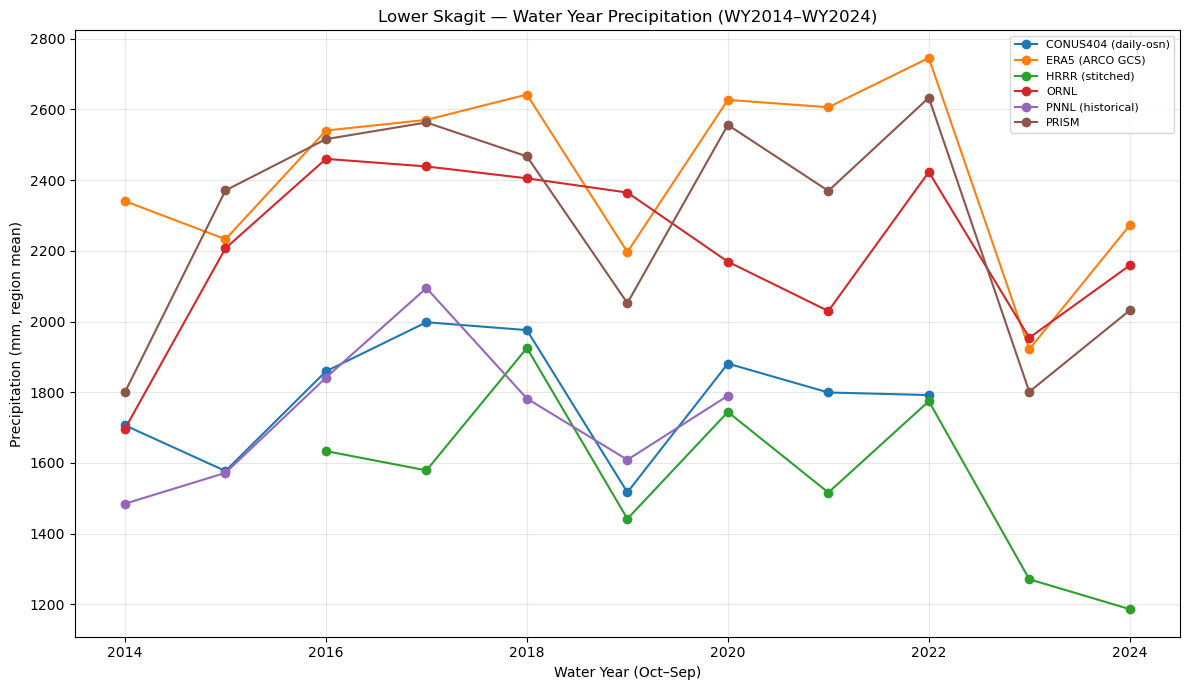

Saved combined plot → /data0/balaji24/data/derived/water_year_precip_skagit_regions_2014_2024_ALL.png


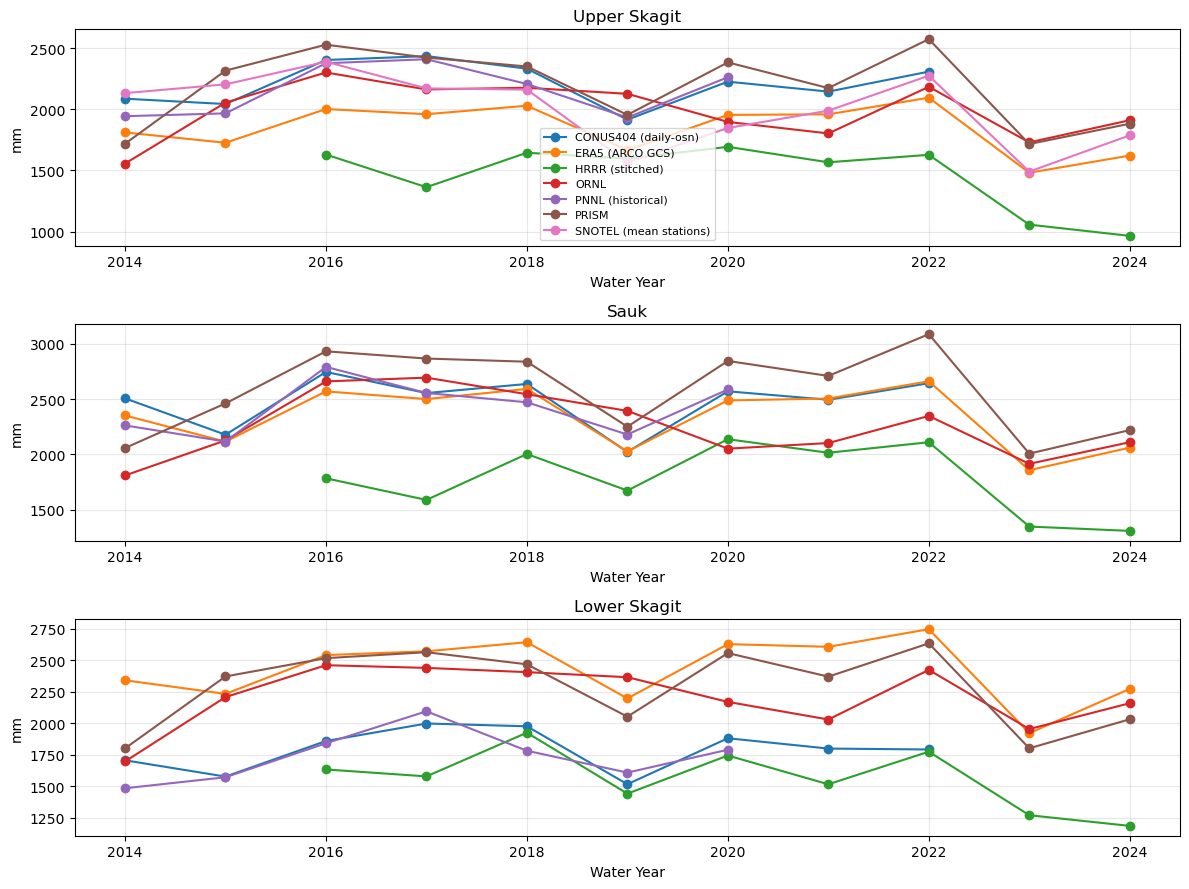


[MAE vs PRISM] Per (region, water year) (mm):
           region  year                 dataset      mae_mm
0    Lower Skagit  2014    CONUS404 (daily-osn)   94.444363
1    Lower Skagit  2014         ERA5 (ARCO GCS)  539.564534
2    Lower Skagit  2014         HRRR (stitched)         NaN
3    Lower Skagit  2014                    ORNL  103.844576
4    Lower Skagit  2014       PNNL (historical)  315.992825
..            ...   ...                     ...         ...
193  Upper Skagit  2024         ERA5 (ARCO GCS)  260.577581
194  Upper Skagit  2024         HRRR (stitched)  918.898812
195  Upper Skagit  2024                    ORNL   28.723287
196  Upper Skagit  2024       PNNL (historical)         NaN
197  Upper Skagit  2024  SNOTEL (mean stations)   95.216084

[198 rows x 4 columns]
Saved MAE CSV → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_2024.csv
Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Upper_Skagit_2014_2024.png


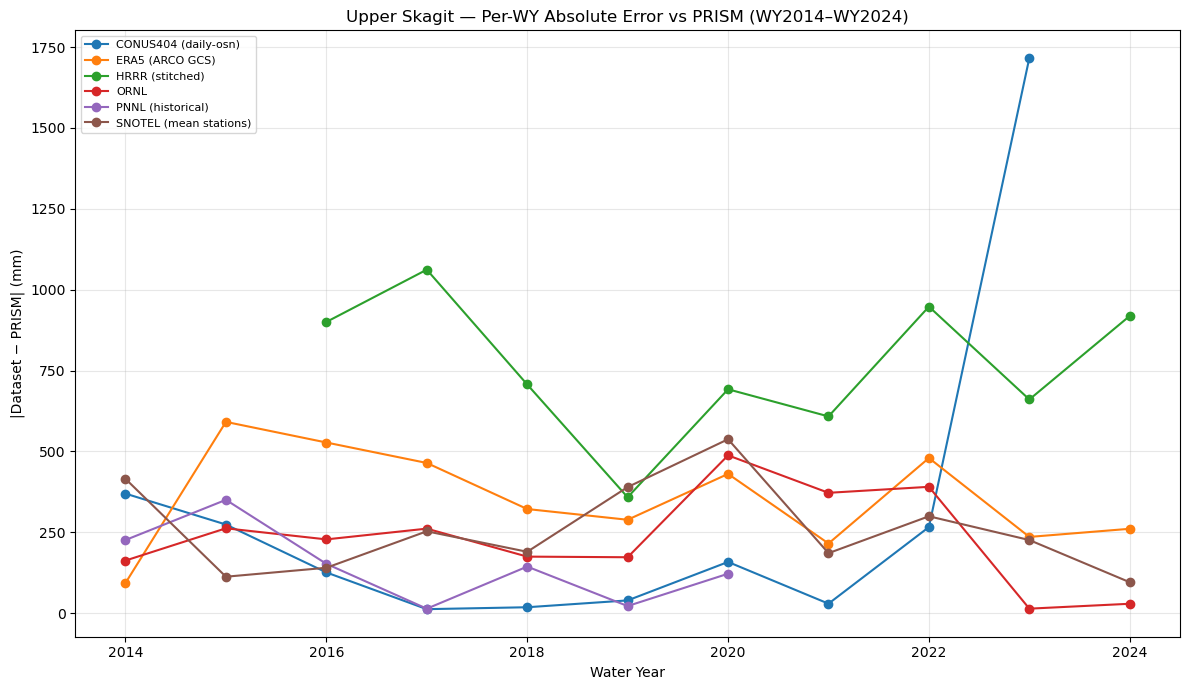

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Sauk_2014_2024.png


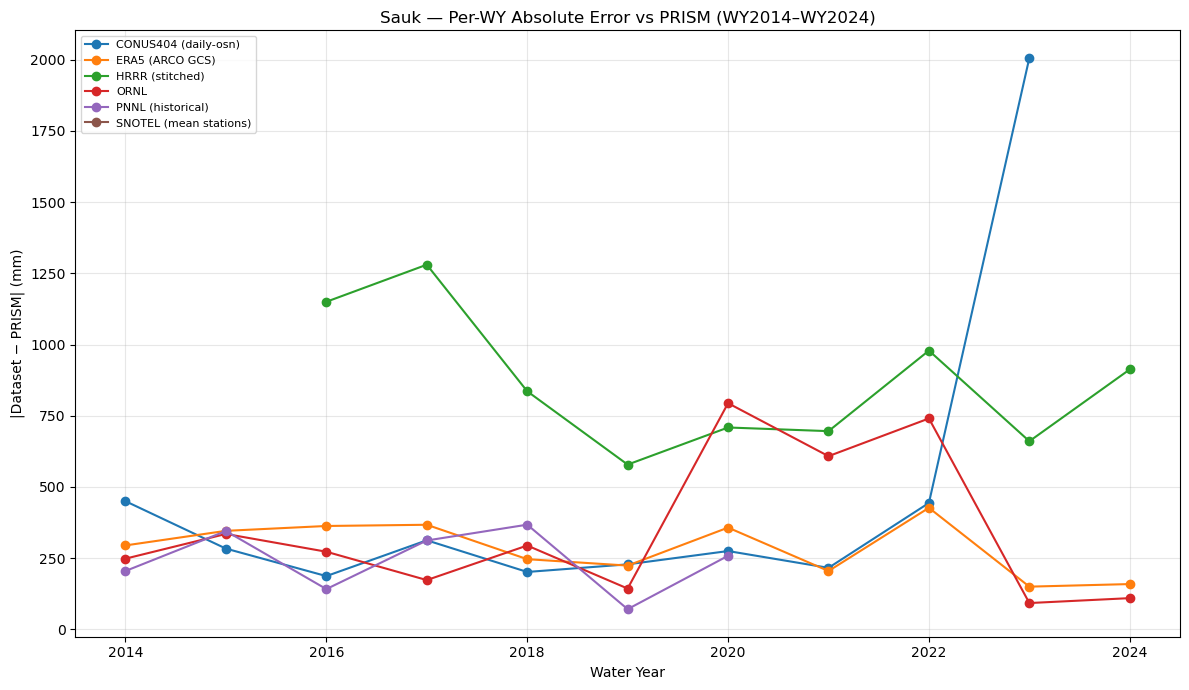

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Lower_Skagit_2014_2024.png


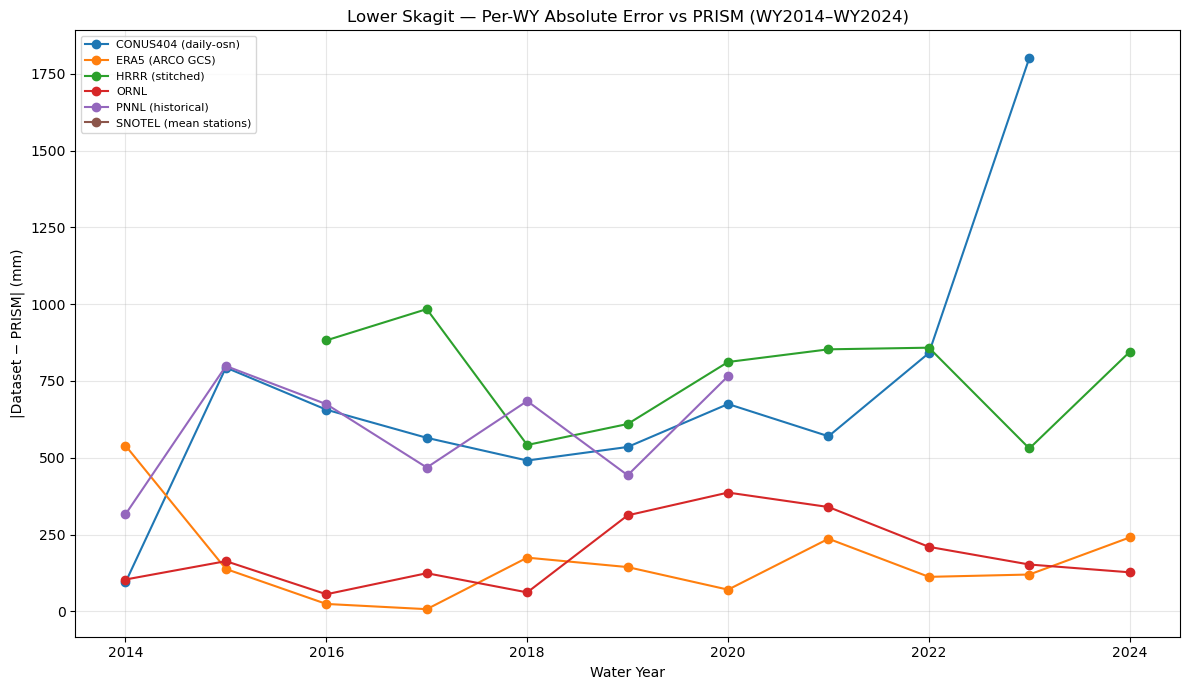

Saved combined MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_2024.png


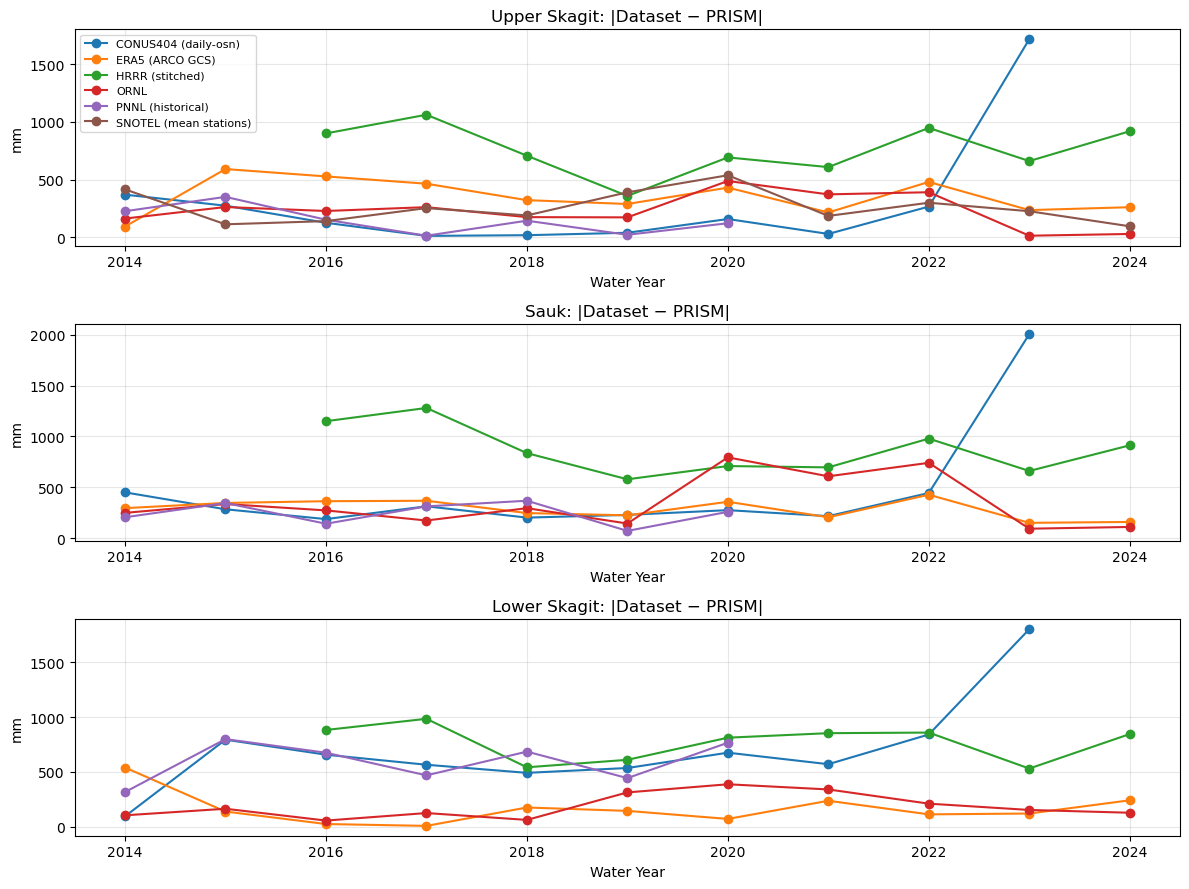

In [ ]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (WY2014–WY2024)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# WATER YEAR: Oct 1 → Sep 30, labeled by ending year
# (WY2014 = 2013-10-01..2014-09-30)
#
# INCLUDED DATASETS (if available):
# - ORNL Daymet (zarr)
# - PRISM (zarr)
# - HRRR (monthly zarr stitched)
# - ERA5 ARCO (public GCS zarr-v3)
# - SNOTEL (egagli repo: station CSVs -> assign to regions -> mean of stations)
# - PNNL historical (hourly NetCDFs; your region mask; strict WY month completeness)
# - CONUS404 daily (HyTEST intake catalog)
#
# ADD:
# - Per-(region,WY) absolute error (|err|) vs PRISM for all other datasets
#
# PLOTTING:
# - Matplotlib, like your Code 1 style:
#   * One figure per region with 3 subplots (WY totals)
#   * Combined summary figure (3 panels, one per region)
#   * Do NOT plot 0 values (convert 0 -> NaN for plotting only)
# ============================

import re
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024  # WATER YEAR labels

# dataset roots
P_ORNL_DIR  = BASE / "ornl"
P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"        # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR   = BASE / "ucla_wrf_outputs"    
PNNL_HIST   = BASE / "PNNL" / "historical" # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT     = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT     = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF     = "PRISM"
MAE_CSV_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower().strip()
    name  = (da.name or "").lower()

    if units in {"m", "meter", "meters", "metre", "metres"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)
    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

# ---- plotting helper: convert 0 -> NaN ONLY for plotting ----
def plot_nozero_line(ax, x, y, *, marker="o", label=None):
    if hasattr(y, "where"):
        y_plot = y.where(y != 0)
    else:
        y_plot = np.where(np.asarray(y) != 0, y, np.nan)
    ax.plot(x, y_plot, marker=marker, label=label)

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """Mean(da) inside each region polygon. Returns DataArray with added 'region' dimension."""
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]

    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)

    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum over water years grouped by WY label. Returns da with dim 'year' (and 'region' if present)."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)
    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                for rname in ann["region"].values:
                    try:
                        val = float(ann.sel(year=wy, region=rname).values)
                    except Exception:
                        val = np.nan
                    if np.isfinite(val):
                        rows.append({"dataset": "ORNL", "region": str(rname), "year": wy, "mm": val})

# ---------- PRISM (daily zarrs) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                for rname in ann["region"].values:
                    try:
                        val = float(ann.sel(year=wy, region=rname).values)
                    except Exception:
                        val = np.nan
                    if np.isfinite(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": wy, "mm": val})

# ---------- HRRR (monthly zarrs; WY-correct + SAFE concat + region masks) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR] WY{wy}: missing months {missing} -> skipping WY{wy}")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for pth in parts:
            dsm = safe_open_zarr(pth)
            if var not in dsm:
                print(f"[HRRR] WY{wy}: {pth.name} missing {var} -> skipping WY{wy}")
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
        daily = hourly_mm.resample(time="1D").sum()

        rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
        rm_daily = ensure_time_sorted_unique(rm_daily)
        rm_daily = rm_daily.sel(time=slice(wy_start(wy), wy_end(wy)))

        wy_tot = rm_daily.sum("time", skipna=True)  # region
        for rname in wy_tot["region"].values:
            val = float(wy_tot.sel(region=rname).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "year": wy, "mm": val})

        print(f"[HRRR] WY{wy}: " + ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values]))

        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ---------- ERA5 (ARCO on GCS) — WATER YEAR, 3 regions ----------
ENABLE_ERA5 = True
ERA5_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
ERA5_DATASET_NAME = "ERA5 (ARCO GCS)"
ERA5_BBOX = dict(lat_min=48.0, lat_max=49.8, lon_min=-123.4, lon_max=-120.2)

if ENABLE_ERA5:
    try:
        import gcsfs  # noqa: F401
    except Exception as e:
        print(f"[ERA5] gcsfs not available ({e}) -> skipping ERA5.")
    else:
        print(f"[ERA5] Opening {ERA5_STORE} (public, anon)...")
        ds_era5 = xr.open_zarr(
            ERA5_STORE,
            consolidated=False,
            storage_options={"token": "anon"},
            chunks={"time": 24 * 14},
        )

        if "total_precipitation" not in ds_era5:
            print("[ERA5] total_precipitation not found -> skipping ERA5.")
        else:
            if "longitude" in ds_era5.coords and float(ds_era5.longitude.min()) >= 0:
                ds_era5 = ds_era5.assign_coords(
                    longitude=(((ds_era5.longitude + 180) % 360) - 180)
                ).sortby("longitude")

            tp = ds_era5["total_precipitation"]
            units = str(tp.attrs.get("units", "")).lower().strip()
            to_mm = 1000.0 if units in {"m", "meter", "meters", "metre", "metres"} else 1.0
            print(f"[ERA5] total_precipitation units={units!r} -> convert_to_mm={to_mm==1000.0}")

            lat0, lat1 = ERA5_BBOX["lat_min"], ERA5_BBOX["lat_max"]
            lat_slice = slice(lat1, lat0) if ds_era5.latitude[0] > ds_era5.latitude[-1] else slice(lat0, lat1)
            lon_slice = slice(ERA5_BBOX["lon_min"], ERA5_BBOX["lon_max"])

            lat_sub = ds_era5["latitude"].sel(latitude=lat_slice)
            lon_sub = ds_era5["longitude"].sel(longitude=lon_slice)
            lon2d, lat2d = xr.broadcast(lon_sub, lat_sub)
            grid_era5 = xr.Dataset({"longitude": lon2d, "latitude": lat2d})

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                t0, t1 = wy_start(wy), wy_end(wy)

                tp_h = (
                    tp.sel(time=slice(t0, t1), latitude=lat_slice, longitude=lon_slice)
                      .astype("float32") * to_mm
                ).clip(min=0)

                if tp_h.sizes.get("time", 0) == 0:
                    continue

                daily = tp_h.resample(time="1D").sum()
                rm_daily = region_mean(daily, grid_ds=grid_era5, regions_gdf=regions_gdf)
                rm_daily = ensure_time_sorted_unique(rm_daily)

                wy_tot = rm_daily.sum("time", skipna=True)  # region
                for rname in wy_tot["region"].values:
                    val = float(wy_tot.sel(region=rname).values)
                    if np.isfinite(val):
                        rows.append({
                            "dataset": ERA5_DATASET_NAME,
                            "region": str(rname),
                            "year": int(wy),
                            "mm": float(val),
                        })

                msg = ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values])
                print(f"[ERA5] WY{wy}: {msg}")

        try:
            ds_era5.close()
        except Exception:
            pass

# ======================================================================
# SNOTEL — ADDED 
# ======================================================================
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(
                    skagit_stations,
                    regs.rename(columns={"Name": "region"}),
                    predicate="within",
                    how="left"
                )
            except TypeError:
                joined = gpd.sjoin(
                    skagit_stations,
                    regs.rename(columns={"Name": "region"}),
                    op="within",
                    how="left"
                )

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f" - {region}: {names}")

                yearly_values = {}  # (region, wy) -> list of station totals
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                for _, row in joined.iterrows():
                    code = row.get("code")
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code}: {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code}, skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)

                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL (historical) — WY regional, STRICT months, memory-safe ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def wy_months_set(wy: int):
    return {(wy - 1, 10), (wy - 1, 11), (wy - 1, 12)} | {(wy, m) for m in range(1, 10)}

def months_present_ym(time_values):
    t = pd.to_datetime(time_values)
    return set(zip(t.year, t.month))

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        need = wy_months_set(wy)
        seen = months_present_ym(p["time"].values)
        missing = sorted(list(need - seen))
        if missing:
            miss_fmt = [f"{yy}-{mm:02d}" for (yy, mm) in missing]
            seen_fmt = sorted({f"{yy}-{mm:02d}" for (yy, mm) in seen})
            print(f"[PNNL] SKIP WY{wy}: missing months {miss_fmt} (seen={seen_fmt[:5]}... n={len(seen_fmt)})")
            dsp.close()
            continue

        P = p.sum(dim="time", skipna=True)

        spatial_dims = [d for d in P.dims if d != "time"]
        if len(spatial_dims) != 2:
            dsp.close()
            raise ValueError(f"[PNNL] Unexpected spatial dims for {v}: {P.dims}")

        for rname in region_labels:
            mr = mask_ds["mask"].sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            mm = float(val.values)
            if np.isfinite(mm):
                rows.append({"dataset": "PNNL (historical)", "region": str(rname), "year": int(wy), "mm": mm})

        dsp.close()

    mask_ds.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)

# ---------- CONUS404 (daily-osn; region masks) ----------
try:
    import intake
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")
        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if np.isfinite(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": wy, "mm": float(val)})

# ---------------- Results: WY totals ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ==========================================================
# Plotting (matplotlib like Code 1)
# - hide zeros on plots ONLY
# ==========================================================
years = list(range(YEAR_MIN, YEAR_MAX + 1))

# One figure per region (single panel, multiple datasets)
for region in REGION_NAMES:
    sub = df[df["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region} — Water Year Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year (Oct–Sep)")
    ax.set_ylabel("Precipitation (mm, region mean)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    out_png = OUT / f"water_year_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined summary: 3 panels (one per region)
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df[df["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(region)
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved combined plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-(region,WY) absolute error vs PRISM
# Since there is ONE value per WY, "MAE per year" == |err|
# ==========================================================
wide = df.pivot_table(index=["region", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, water year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region
for region in REGION_NAMES:
    sub = mae_long[mae_long["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mae_mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region} — Per-WY Absolute Error vs {MAE_REF} (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year")
    ax.set_ylabel(f"|Dataset − {MAE_REF}| (mm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    out_png = OUT / f"water_year_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Combined MAE summary: 3 panels (one per region)
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_long[mae_long["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mae_mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region}: |Dataset − {MAE_REF}|")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved combined MAE plot →", MAE_PNG_OUT)
plt.show()


# ORNL and UCLA ERA5 updated

ERROR 1: PROJ: proj_create_from_database: Open of /home/balaji24/skagit-met/.pixi/envs/analysis/share/proj failed


[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09'] -> skipping WY2014
[HRRR] WY2015: missing months ['2014-10', '2014-11'] -> skipping WY2015
[HRRR] WY2016: Upper Skagit=1630.6, Sauk=1782.7, Lower Skagit=1633.6
[HRRR] WY2017: Upper Skagit=1363.2, Sauk=1587.0, Lower Skagit=1579.0
[HRRR] WY2018: Upper Skagit=1645.3, Sauk=2002.6, Lower Skagit=1925.2
[HRRR] WY2019: Upper Skagit=1597.5, Sauk=1671.6, Lower Skagit=1442.2
[HRRR] WY2020: Upper Skagit=1693.6, Sauk=2136.6, Lower Skagit=1744.2
[HRRR] WY2021: Upper Skagit=1567.2, Sauk=2014.1, Lower Skagit=1516.4
[HRRR] WY2022: Upper Skagit=1628.3, Sauk=2109.2, Lower Skagit=1774.7
[HRRR] WY2023: Upper Skagit=1056.3, Sauk=1345.8, Lower Skagit=1271.2
[HRRR] WY2024: Upper Skagit=964.2, Sauk=1306.6, Lower Skagit=1186.7
[UCLA MASK] Upper Skagit: 61 cells inside (of 91800)
[UCLA MASK] Sauk: 22 c

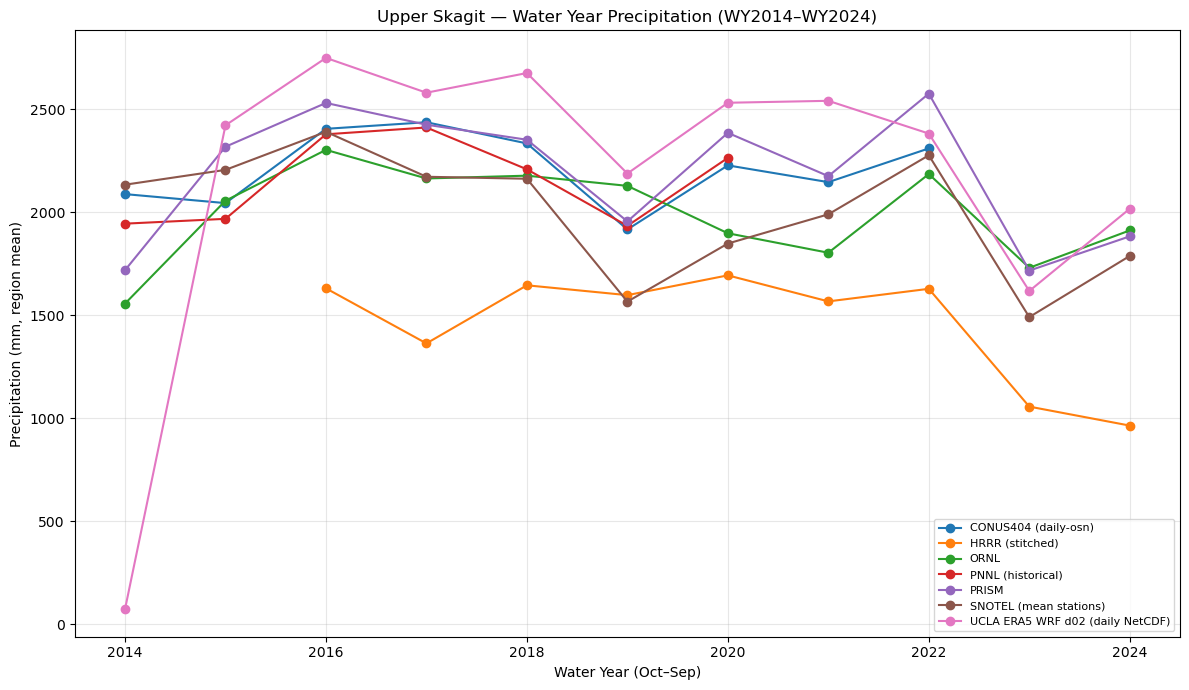

Saved plot → /data0/balaji24/data/derived/water_year_precip_Sauk_2014_2024.png


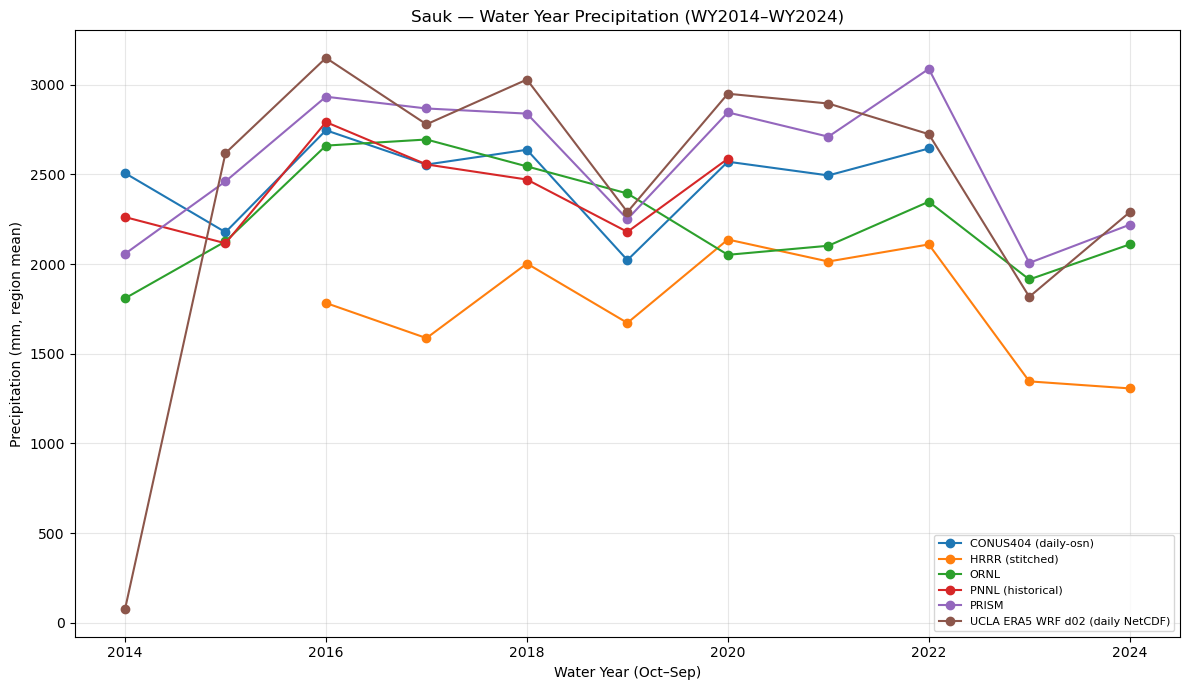

Saved plot → /data0/balaji24/data/derived/water_year_precip_Lower_Skagit_2014_2024.png


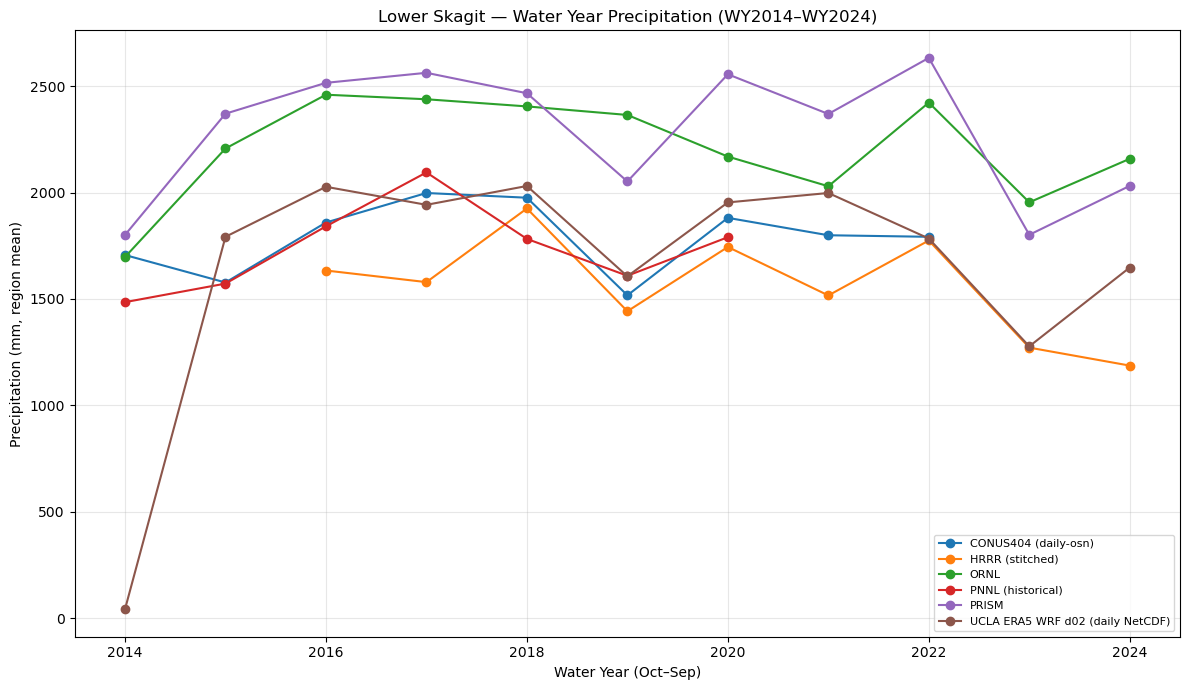

Saved combined plot → /data0/balaji24/data/derived/water_year_precip_skagit_regions_2014_2024_ALL.png


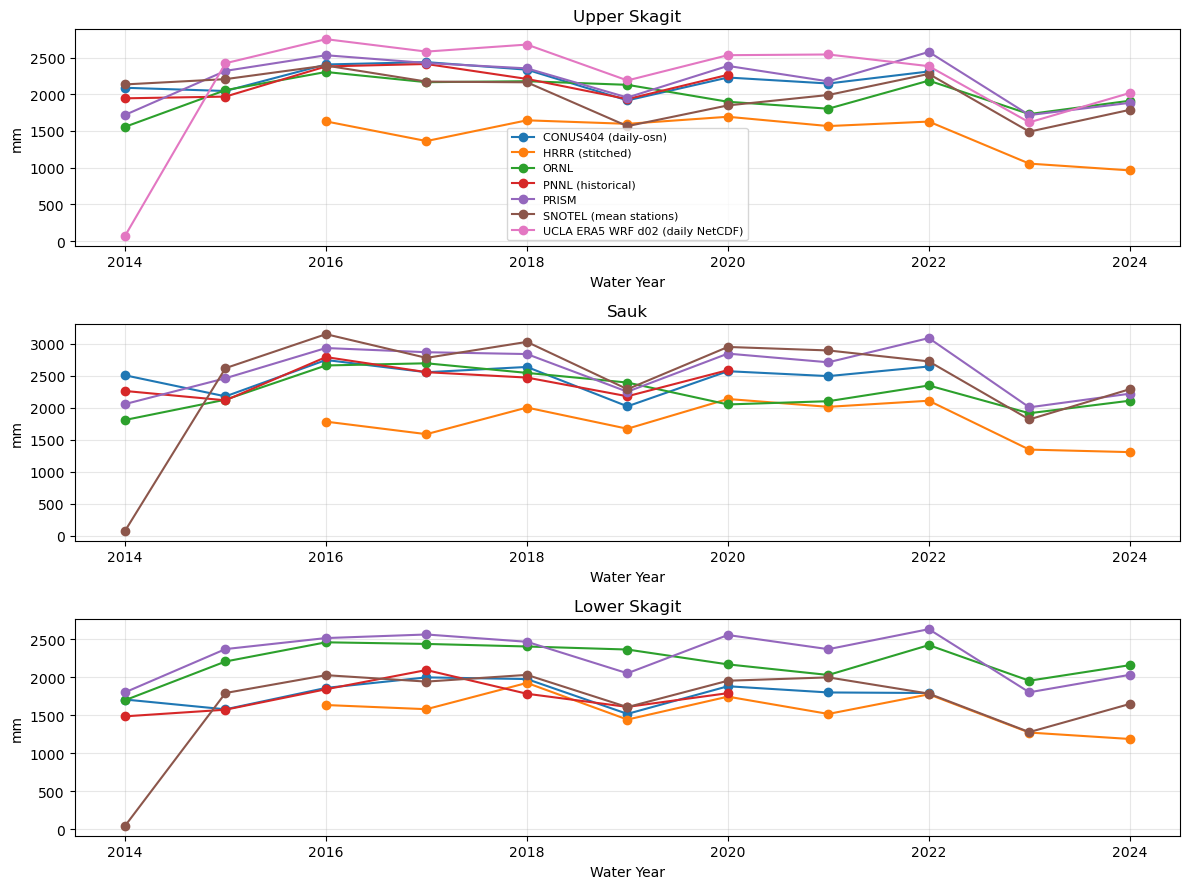


[MAE vs PRISM] Per (region, water year) (mm):
           region  year                           dataset      mae_mm
0    Lower Skagit  2014              CONUS404 (daily-osn)   94.444363
1    Lower Skagit  2014                   HRRR (stitched)         NaN
2    Lower Skagit  2014                              ORNL  103.844576
3    Lower Skagit  2014                 PNNL (historical)  315.992825
4    Lower Skagit  2014            SNOTEL (mean stations)         NaN
..            ...   ...                               ...         ...
193  Upper Skagit  2024                   HRRR (stitched)  918.898812
194  Upper Skagit  2024                              ORNL   28.723287
195  Upper Skagit  2024                 PNNL (historical)         NaN
196  Upper Skagit  2024            SNOTEL (mean stations)   95.216084
197  Upper Skagit  2024  UCLA ERA5 WRF d02 (daily NetCDF)  134.073752

[198 rows x 4 columns]
Saved MAE CSV → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_

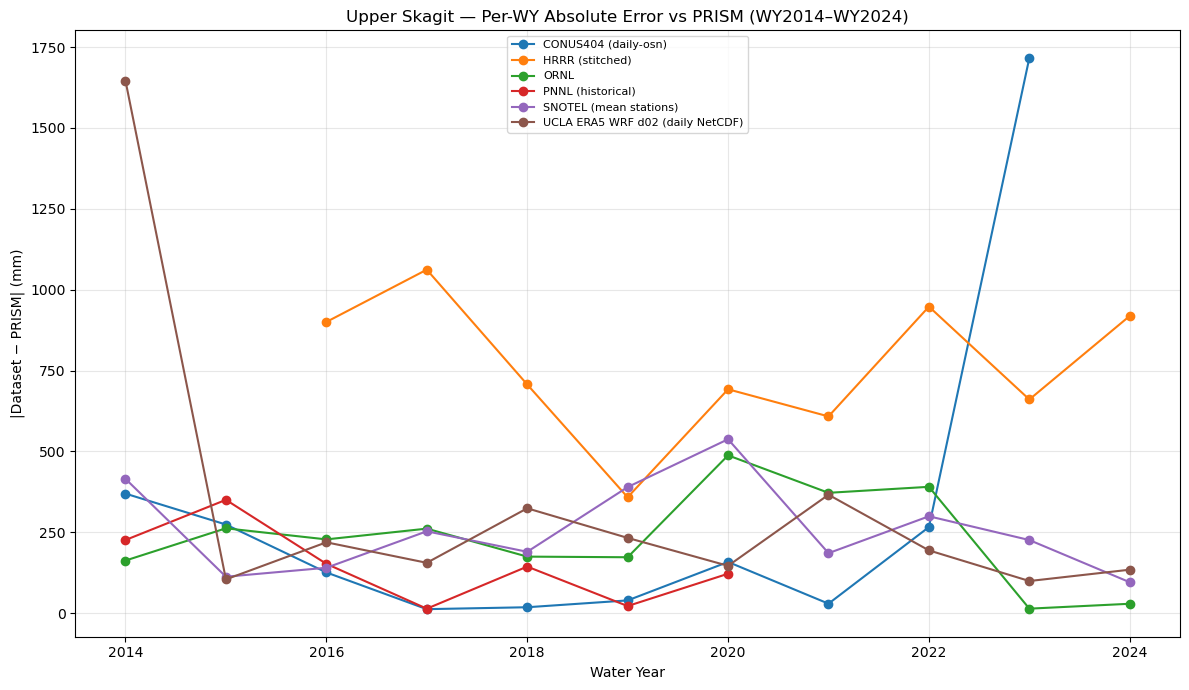

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Sauk_2014_2024.png


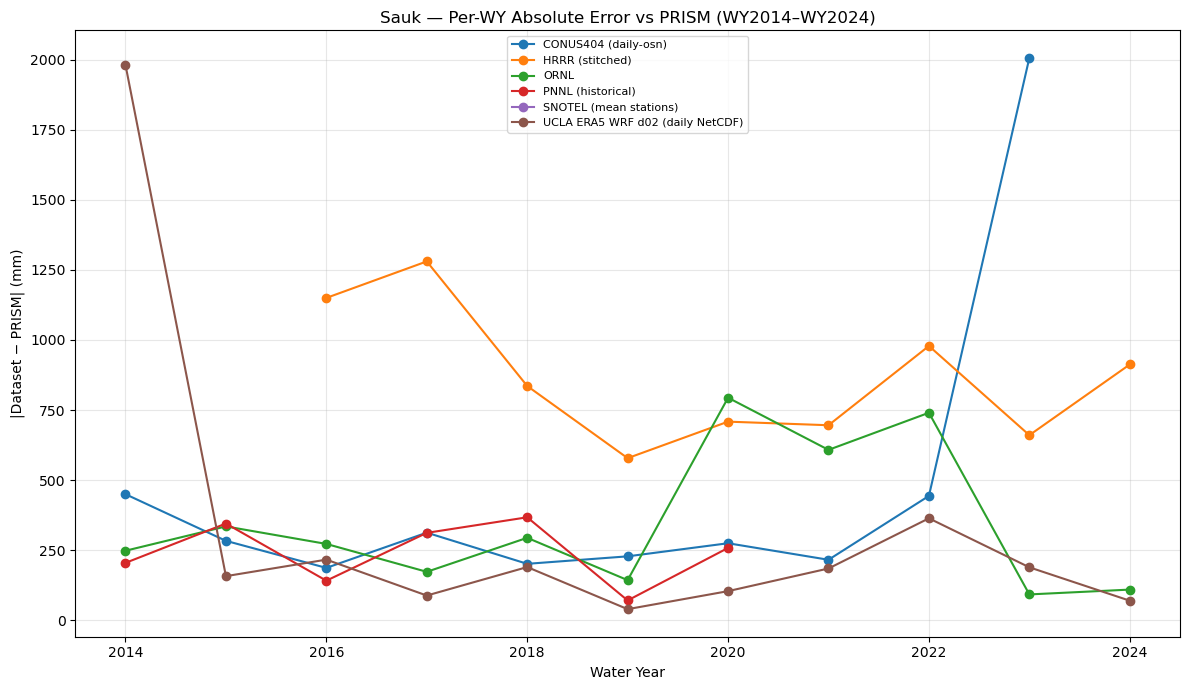

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Lower_Skagit_2014_2024.png


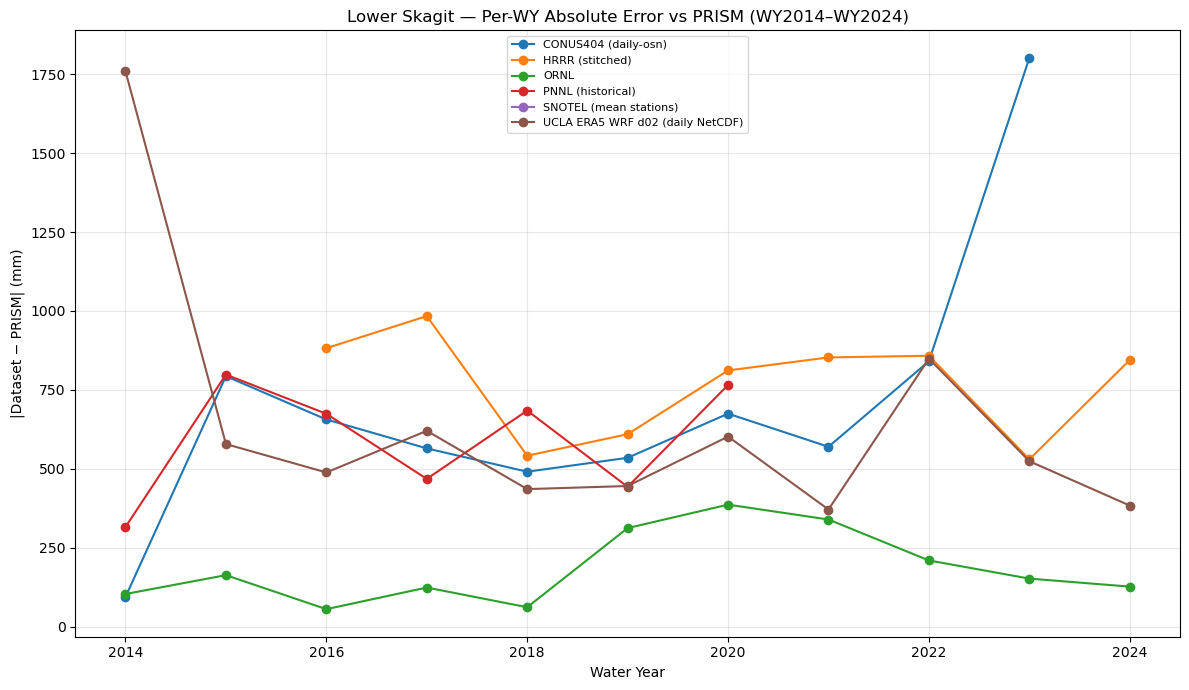

Saved combined MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_2024.png


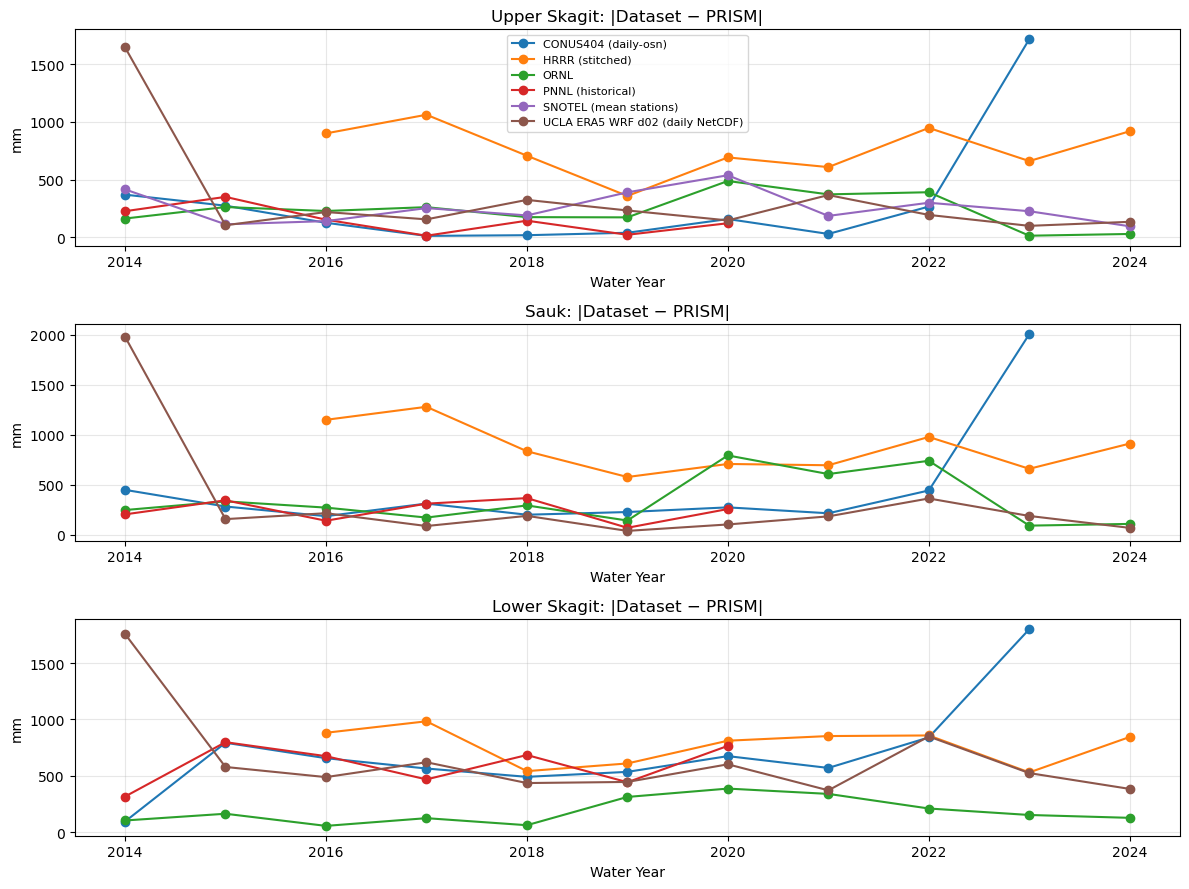

Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

In [ ]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (WY2014–WY2024)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# WATER YEAR: Oct 1 → Sep 30, labeled by ending year
# (WY2014 = 2013-10-01..2014-09-30)
#
# INCLUDED DATASETS (if available):
# - ORNL Daymet (zarr)
# - PRISM (zarr)
# - HRRR (monthly zarr stitched)
# - UCLA ERA5 WRF d02 (daily NetCDF)  UPDATED (replaces ERA5 ARCO section)
# - SNOTEL (egagli repo: station CSVs -> assign to regions -> mean of stations)
# - PNNL historical (hourly NetCDFs; your region mask; strict WY month completeness)
# - CONUS404 daily (HyTEST intake catalog)
#
# ADD:
# - Per-(region,WY) absolute error (|err|) vs PRISM for all other datasets
#
# PLOTTING:
# - Matplotlib, like your Code 1 style:
#   * One figure per region with WY totals
#   * Combined summary figure (3 panels, one per region)
#   * Do NOT plot 0 values (convert 0 -> NaN for plotting only)
# ============================

import re
from pathlib import Path
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024  # WATER YEAR labels

# dataset roots
P_ORNL_DIR  = BASE / "ornl"
P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"        # many YYYY-MM_HRRR_data.zarr
P_WRF_DIR   = BASE / "ucla_wrf_outputs"    
PNNL_HIST   = BASE / "PNNL" / "historical" # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT     = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT     = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF     = "PRISM"
MAE_CSV_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = xr.DataArray(da["time"].values)
        _, idx = np.unique(t.values, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

def to_incremental_mm(da, force_cumulative=False):
    """Normalize precip to incremental per-step in mm; deaccumulate if cumulative."""
    units = str(da.attrs.get("units", "")).lower().strip()
    name  = (da.name or "").lower()

    if units in {"m", "meter", "meters", "metre", "metres"}:
        da = da * 1000.0
        da.attrs["units"] = "mm"

    if "kg m" in units and "-2" in units:
        da.attrs["units"] = "mm"

    is_cum = (
        force_cumulative
        or any(k in name for k in ["prec_acc_nc", "rainnc", "rainc", "acc"])
        or ("cumulative" in units)
    )

    da = ensure_time_sorted_unique(da)
    if is_cum:
        inc = da.diff("time", label="upper")
        inc = inc.where(inc >= 0, 0)  # clip resets
        inc = xr.concat([da.isel(time=slice(0, 1)) * 0, inc], dim="time")
        inc.attrs["units"] = "mm"
        return inc

    return da

# ---- plotting helper: convert 0 -> NaN ONLY for plotting ----
def plot_nozero_line(ax, x, y, *, marker="o", label=None):
    if hasattr(y, "where"):
        y_plot = y.where(y != 0)
    else:
        y_plot = np.where(np.asarray(y) != 0, y, np.nan)
    ax.plot(x, y_plot, marker=marker, label=label)

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """Mean(da) inside each region polygon. Returns DataArray with added 'region' dimension."""
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]

    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)

    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum over water years grouped by WY label. Returns da with dim 'year' (and 'region' if present)."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"])
    out = da.groupby(wy).sum("time", skipna=True)
    out = out.rename({"group": "year"}) if "group" in out.dims else out
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)
    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ---------- ORNL (Daymet: mm/day) ----------
if P_ORNL_DIR.exists():
    ornl_years = sorted(P_ORNL_DIR.glob("*_ORNL_data.zarr"))
    if ornl_years:
        dso = xr.concat(
            [safe_open_zarr(p) for p in ornl_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        if "prcp" in dso:
            da = ensure_time_sorted_unique(dso["prcp"])
            rm = region_mean(da, grid_ds=dso, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                for rname in ann["region"].values:
                    try:
                        val = float(ann.sel(year=wy, region=rname).values)
                    except Exception:
                        val = np.nan
                    if np.isfinite(val):
                        rows.append({"dataset": "ORNL", "region": str(rname), "year": wy, "mm": val})

# ---------- PRISM (daily zarrs) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                for rname in ann["region"].values:
                    try:
                        val = float(ann.sel(year=wy, region=rname).values)
                    except Exception:
                        val = np.nan
                    if np.isfinite(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": wy, "mm": val})

# ---------- HRRR (monthly zarrs; WY-correct + SAFE concat + region masks) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR] WY{wy}: missing months {missing} -> skipping WY{wy}")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for pth in parts:
            dsm = safe_open_zarr(pth)
            if var not in dsm:
                print(f"[HRRR] WY{wy}: {pth.name} missing {var} -> skipping WY{wy}")
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
        daily = hourly_mm.resample(time="1D").sum()

        rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
        rm_daily = ensure_time_sorted_unique(rm_daily)
        rm_daily = rm_daily.sel(time=slice(wy_start(wy), wy_end(wy)))

        wy_tot = rm_daily.sum("time", skipna=True)  # region
        for rname in wy_tot["region"].values:
            val = float(wy_tot.sel(region=rname).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "year": wy, "mm": val})

        print(f"[HRRR] WY{wy}: " + ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values]))

        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ==========================================================
# UCLA ERA5 WRF d02 (daily NetCDF) — WATER YEAR, 3 regions
# Assumes files are labeled by water-year style:
#   prec.daily.era5.d02.{Y}.nc covers Sep(Y) .. Aug(Y+1)
# ==========================================================
UCLA_DATASET_NAME = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    # UCLA file {Y}.nc covers Sep(Y)..Aug(Y+1)
    # So Sep-Dec => label=year; Jan-Aug => label=year-1
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue

        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})

        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time")
    pr_all = pr_all.sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]

        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
        print(f"[UCLA MASK] {name}: {int(mask2d.sum())} cells inside (of {mask2d.size})")

    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        t0, t1 = wy_start(wy), wy_end(wy)

        pr, parents = open_ucla_prec_for_window(t0, t1)
        if pr is None:
            continue

        try:
            # Optional unit normalization (only if needed)
            units = str(pr.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                pr = pr * 1000.0
                pr.attrs["units"] = "mm"

            for rname in REGION_NAMES:
                mask = UCLA_REGION_MASKS.get(rname)
                if mask is None:
                    continue

                ts = masked_mean_timeseries(pr, mask)
                val = float(ts.sum(dim="time", skipna=True).compute().values)

                if np.isfinite(val):
                    rows.append({
                        "dataset": UCLA_DATASET_NAME,
                        "region": str(rname),
                        "year": int(wy),
                        "mm": float(val),
                    })

            try:
                msg = ", ".join([
                    f"{r}={float(masked_mean_timeseries(pr, UCLA_REGION_MASKS[r]).sum('time', skipna=True).compute().values):.1f}"
                    for r in REGION_NAMES if r in UCLA_REGION_MASKS
                ])
                print(f"[UCLA] WY{wy}: {msg}")
            except Exception:
                print(f"[UCLA] WY{wy}: computed")

        finally:
            for ds in parents:
                try: ds.close()
                except Exception: pass
else:
    print("[UCLA] Missing UCLA precip dir or coord file -> skipping UCLA.")

# ======================================================================
# SNOTEL (unchanged)
# ======================================================================
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(
                    skagit_stations,
                    regs.rename(columns={"Name": "region"}),
                    predicate="within",
                    how="left"
                )
            except TypeError:
                joined = gpd.sjoin(
                    skagit_stations,
                    regs.rename(columns={"Name": "region"}),
                    op="within",
                    how="left"
                )

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                print("[SNOTEL] Using stations by region:")
                for region in REGION_NAMES:
                    sub = joined[joined["region"] == region]
                    if sub.empty:
                        continue
                    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
                    print(f" - {region}: {names}")

                yearly_values = {}  # (region, wy) -> list of station totals
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                for _, row in joined.iterrows():
                    code = row.get("code")
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code}: {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        print(f"[SNOTEL] No PRCPSA for {code}, skipping.")
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)

                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL (historical) — WY regional, STRICT months, memory-safe ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def wy_months_set(wy: int):
    return {(wy - 1, 10), (wy - 1, 11), (wy - 1, 12)} | {(wy, m) for m in range(1, 10)}

def months_present_ym(time_values):
    t = pd.to_datetime(time_values)
    return set(zip(t.year, t.month))

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    if "mask" not in mask_ds:
        raise ValueError("[PNNL] Expected variable 'mask' in PNNL_REGION_MASK")
    if "region" not in mask_ds["mask"].dims:
        raise ValueError("[PNNL] Expected 'mask' to have a 'region' dimension")

    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        need = wy_months_set(wy)
        seen = months_present_ym(p["time"].values)
        missing = sorted(list(need - seen))
        if missing:
            miss_fmt = [f"{yy}-{mm:02d}" for (yy, mm) in missing]
            seen_fmt = sorted({f"{yy}-{mm:02d}" for (yy, mm) in seen})
            print(f"[PNNL] SKIP WY{wy}: missing months {miss_fmt} (seen={seen_fmt[:5]}... n={len(seen_fmt)})")
            dsp.close()
            continue

        P = p.sum(dim="time", skipna=True)

        spatial_dims = [d for d in P.dims if d != "time"]
        if len(spatial_dims) != 2:
            dsp.close()
            raise ValueError(f"[PNNL] Unexpected spatial dims for {v}: {P.dims}")

        for rname in region_labels:
            mr = mask_ds["mask"].sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            mm = float(val.values)
            if np.isfinite(mm):
                rows.append({"dataset": "PNNL (historical)", "region": str(rname), "year": int(wy), "mm": mm})

        dsp.close()

    mask_ds.close()
else:
    if PNNL_HIST.exists():
        print("[PNNL] Skipping regional PNNL: missing region mask file:", PNNL_REGION_MASK)

# ---------- CONUS404 (daily-osn; region masks) ----------
try:
    import intake
    import shapely
except ImportError as e:
    print(f"[CONUS404] Missing dependency ({e}), skipping CONUS404.")
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")
        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if np.isfinite(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": wy, "mm": float(val)})

# ---------------- Results: WY totals ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ==========================================================
# Plotting (matplotlib like Code 1)
# - hide zeros on plots ONLY
# ==========================================================
# One figure per region (single panel, multiple datasets)
for region in REGION_NAMES:
    sub = df[df["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region} — Water Year Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year (Oct–Sep)")
    ax.set_ylabel("Precipitation (mm, region mean)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    out_png = OUT / f"water_year_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined summary: 3 panels (one per region)
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df[df["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(region)
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved combined plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-(region,WY) absolute error vs PRISM
# Since there is ONE value per WY, "MAE per year" == |err|
# ==========================================================
wide = df.pivot_table(index=["region", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs()
abs_err = abs_err.drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, water year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region
for region in REGION_NAMES:
    sub = mae_long[mae_long["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mae_mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region} — Per-WY Absolute Error vs {MAE_REF} (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year")
    ax.set_ylabel(f"|Dataset − {MAE_REF}| (mm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    out_png = OUT / f"water_year_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Combined MAE summary: 3 panels (one per region)
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_long[mae_long["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mae_mm"].astype(float)
        y = y.where(y != 0, np.nan)  # hide zeros on plot
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region}: |Dataset − {MAE_REF}|")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved combined MAE plot →", MAE_PNG_OUT)
plt.show()

# Final graphs after ORNL Fix

ERROR 1: PROJ: proj_create_from_database: Open of /home/balaji24/skagit-met/.pixi/envs/analysis/share/proj failed


[DAYMET-PC] WY2014: Upper Skagit=1984.6, Sauk=2330.5, Lower Skagit=2212.6
[DAYMET-PC] WY2015: Upper Skagit=2055.8, Sauk=2135.4, Lower Skagit=2173.3


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff8198e2490>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff812d099d0>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7ff812cee270>, 348734.516593276)])']
connector: <aiohttp.connector.TCPConnector object at 0x7ff812d09bd0>
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out


[DAYMET-PC] WY2016: Upper Skagit=2304.8, Sauk=2673.6, Lower Skagit=2432.0
[DAYMET-PC] WY2017: Upper Skagit=2163.5, Sauk=2706.3, Lower Skagit=2407.5
[DAYMET-PC] WY2018: Upper Skagit=2178.6, Sauk=2560.6, Lower Skagit=2380.5
[DAYMET-PC] WY2019: Upper Skagit=1840.3, Sauk=1981.6, Lower Skagit=1929.0
[DAYMET-PC] WY2020: Upper Skagit=2154.9, Sauk=2448.1, Lower Skagit=2336.4
[DAYMET-PC] WY2021: Upper Skagit=898.4, Sauk=1078.3, Lower Skagit=960.6
[DAYMET-PC] WY2022: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0
[DAYMET-PC] WY2023: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0
[DAYMET-PC] WY2024: Upper Skagit=0.0, Sauk=0.0, Lower Skagit=0.0


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff8199089d0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff81865c990>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff819914b90>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff812cc8bd0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff8198e6250>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff8187a3f10>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7ff812e49550>, 349583.268870352)])']
connector: <aiohttp.connector.TCPConnector object at 0x7ff812e74310>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7ff8185ea850>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7ff812e4a9e0>, 349587.500794441), (<ai

[HRRR] months available: 2014-12 … 2024-12 (n=121)
[HRRR] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06', '2014-07', '2014-08', '2014-09'] -> skipping WY2014
[HRRR] WY2015: missing months ['2014-10', '2014-11'] -> skipping WY2015
[HRRR] WY2016: Upper Skagit=1630.6, Sauk=1782.7, Lower Skagit=1633.6


Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

[HRRR] WY2017: Upper Skagit=1363.2, Sauk=1587.0, Lower Skagit=1579.0
[HRRR] WY2018: Upper Skagit=1645.3, Sauk=2002.6, Lower Skagit=1925.2
[HRRR] WY2019: Upper Skagit=1597.5, Sauk=1671.6, Lower Skagit=1442.2
[HRRR] WY2020: Upper Skagit=1693.6, Sauk=2136.6, Lower Skagit=1744.2
[HRRR] WY2021: Upper Skagit=1567.2, Sauk=2014.1, Lower Skagit=1516.4
[HRRR] WY2022: Upper Skagit=1628.3, Sauk=2109.2, Lower Skagit=1774.7
[HRRR] WY2023: Upper Skagit=1056.3, Sauk=1345.8, Lower Skagit=1271.2
[HRRR] WY2024: Upper Skagit=964.2, Sauk=1306.6, Lower Skagit=1186.7
[UCLA MASK] Upper Skagit: 61 cells inside (of 91800)
[UCLA MASK] Sauk: 22 cells inside (of 91800)
[UCLA MASK] Lower Skagit: 11 cells inside (of 91800)
[UCLA] WY2014: Upper Skagit=72.8, Sauk=75.9, Lower Skagit=41.8
[UCLA] WY2015: Upper Skagit=2422.2, Sauk=2618.3, Lower Skagit=1792.1
[UCLA] WY2016: Upper Skagit=2749.5, Sauk=3149.2, Lower Skagit=2027.1
[UCLA] WY2017: Upper Skagit=2580.5, Sauk=2778.8, Lower Skagit=1942.4
[UCLA] WY2018: Upper Skagit=

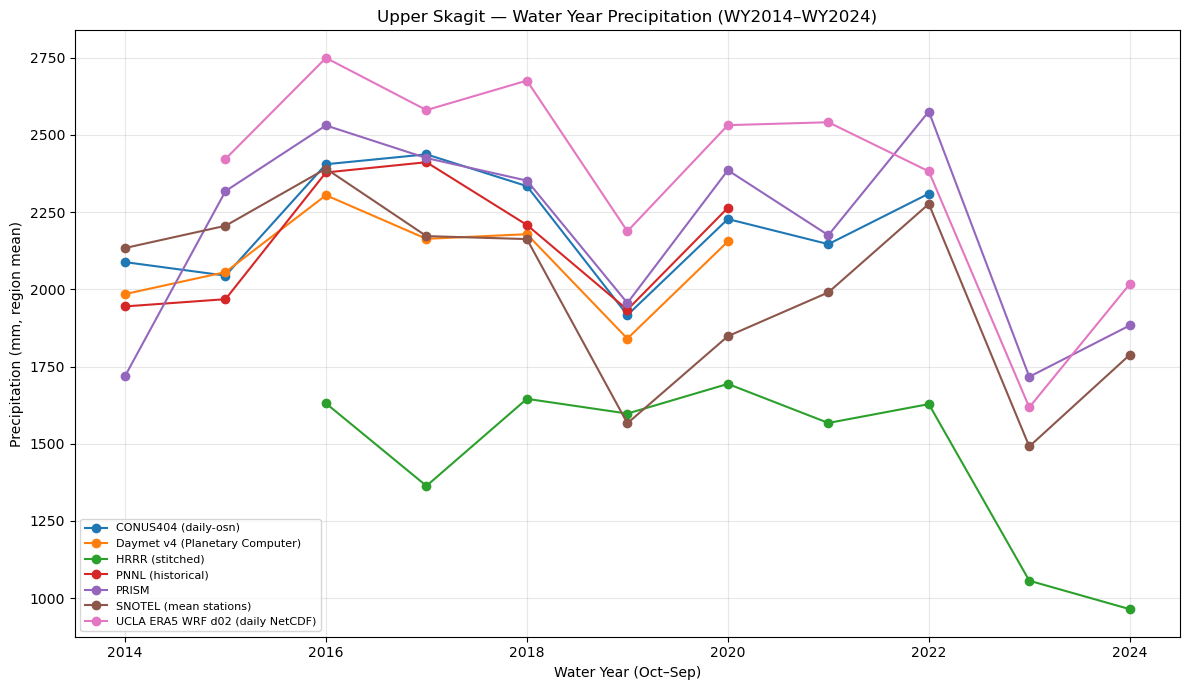

Saved plot → /data0/balaji24/data/derived/water_year_precip_Sauk_2014_2024.png


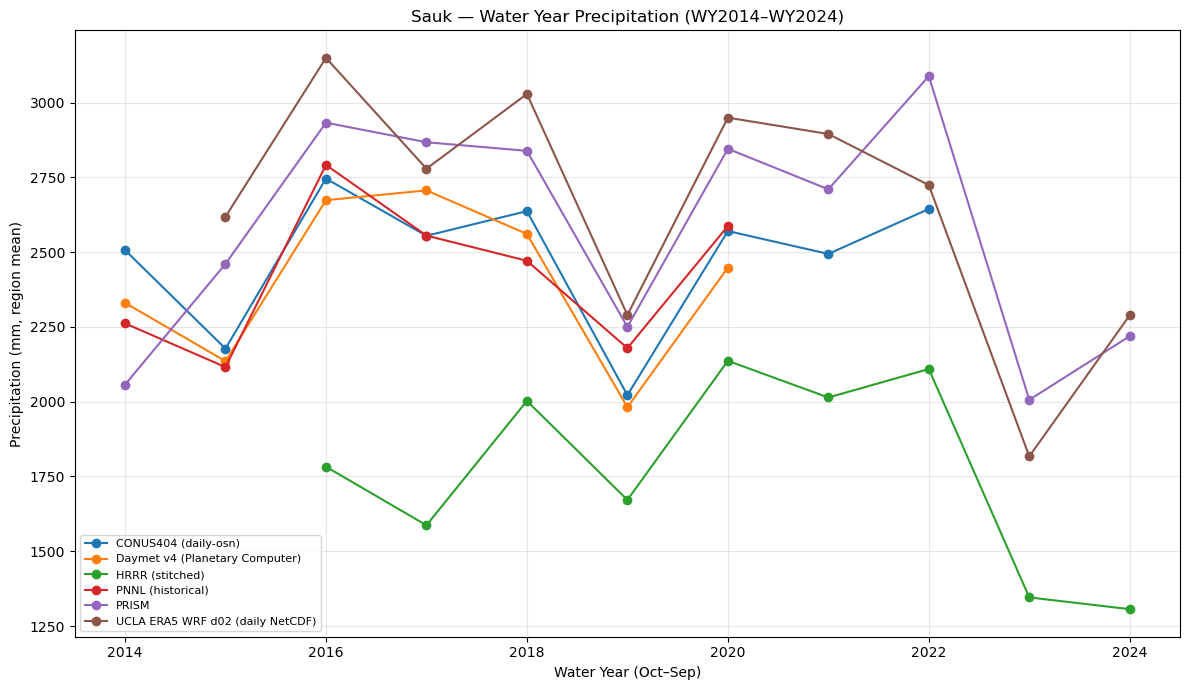

Saved plot → /data0/balaji24/data/derived/water_year_precip_Lower_Skagit_2014_2024.png


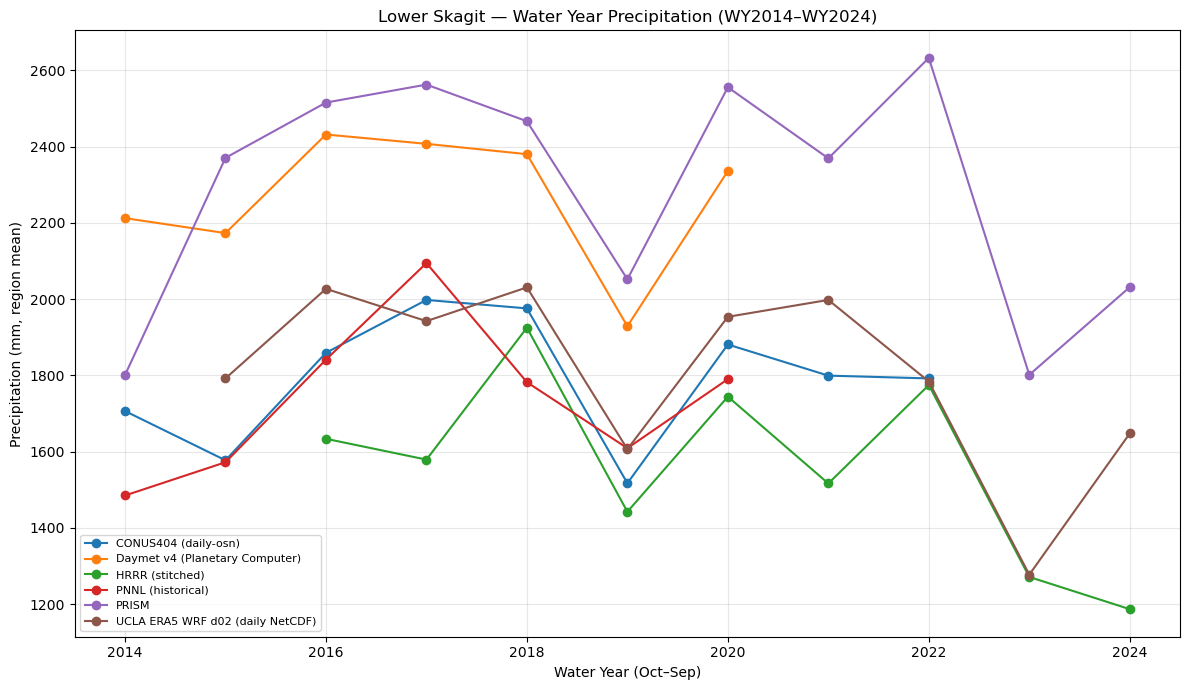

Saved combined plot → /data0/balaji24/data/derived/water_year_precip_skagit_regions_2014_2024_ALL.png


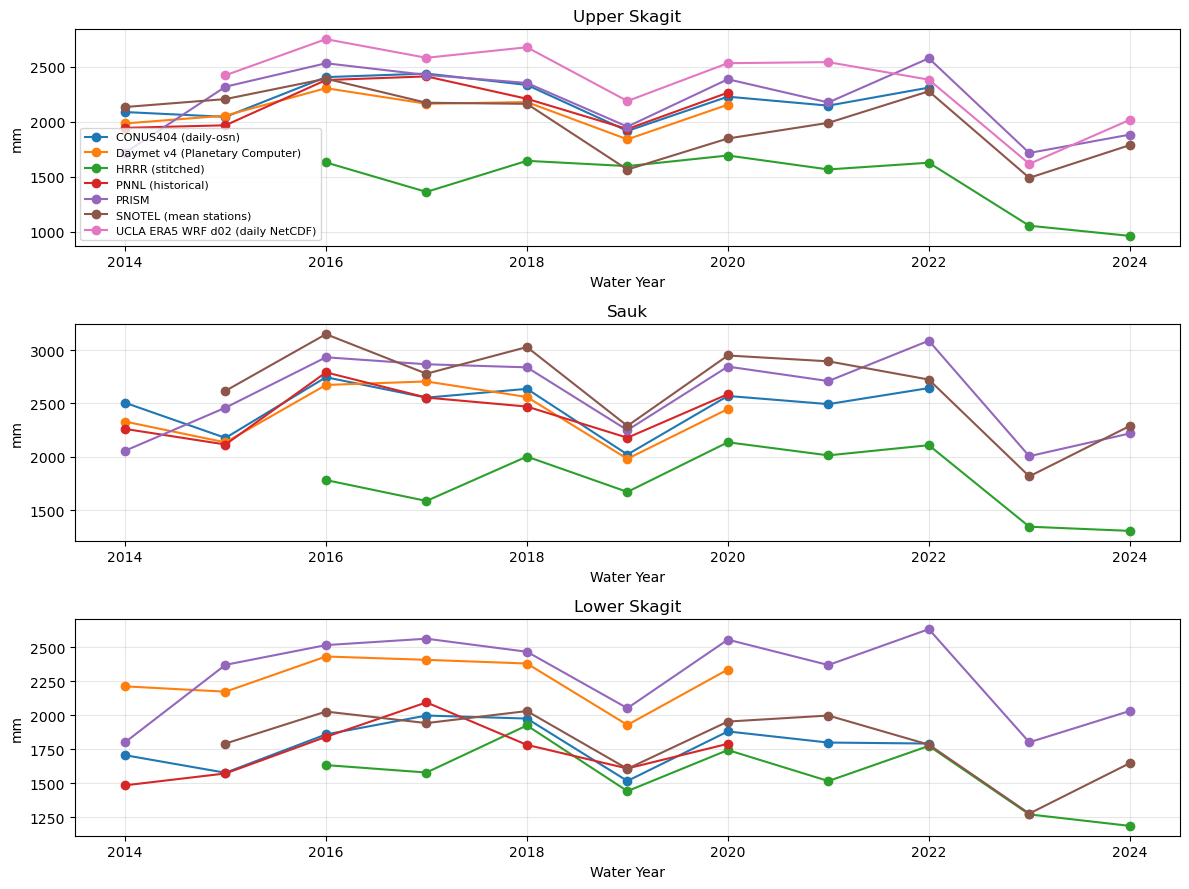


[MAE vs PRISM] Per (region, water year) (mm):
           region  year                           dataset       mae_mm
0    Lower Skagit  2014              CONUS404 (daily-osn)    94.444363
1    Lower Skagit  2014    Daymet v4 (Planetary Computer)   411.694187
2    Lower Skagit  2014                   HRRR (stitched)          NaN
3    Lower Skagit  2014                 PNNL (historical)   315.992825
4    Lower Skagit  2014            SNOTEL (mean stations)          NaN
..            ...   ...                               ...          ...
193  Upper Skagit  2024    Daymet v4 (Planetary Computer)  1883.049417
194  Upper Skagit  2024                   HRRR (stitched)   918.898812
195  Upper Skagit  2024                 PNNL (historical)          NaN
196  Upper Skagit  2024            SNOTEL (mean stations)    95.216084
197  Upper Skagit  2024  UCLA ERA5 WRF d02 (daily NetCDF)   134.073752

[198 rows x 4 columns]
Saved MAE CSV → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_r

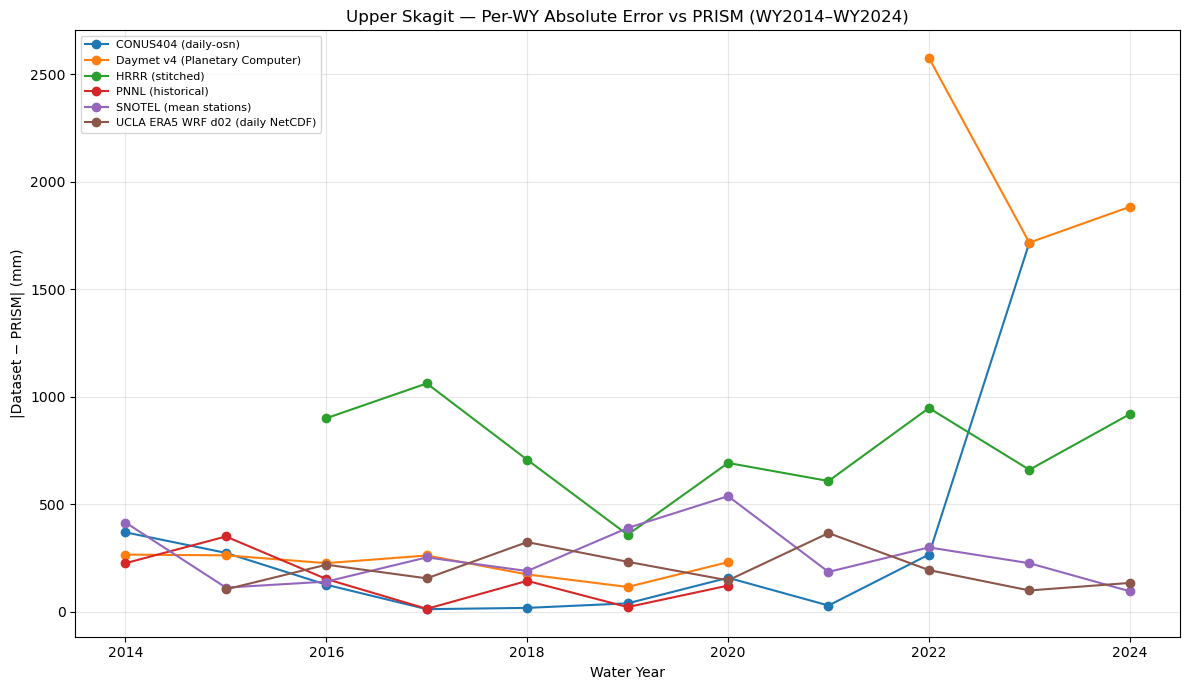

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Sauk_2014_2024.png


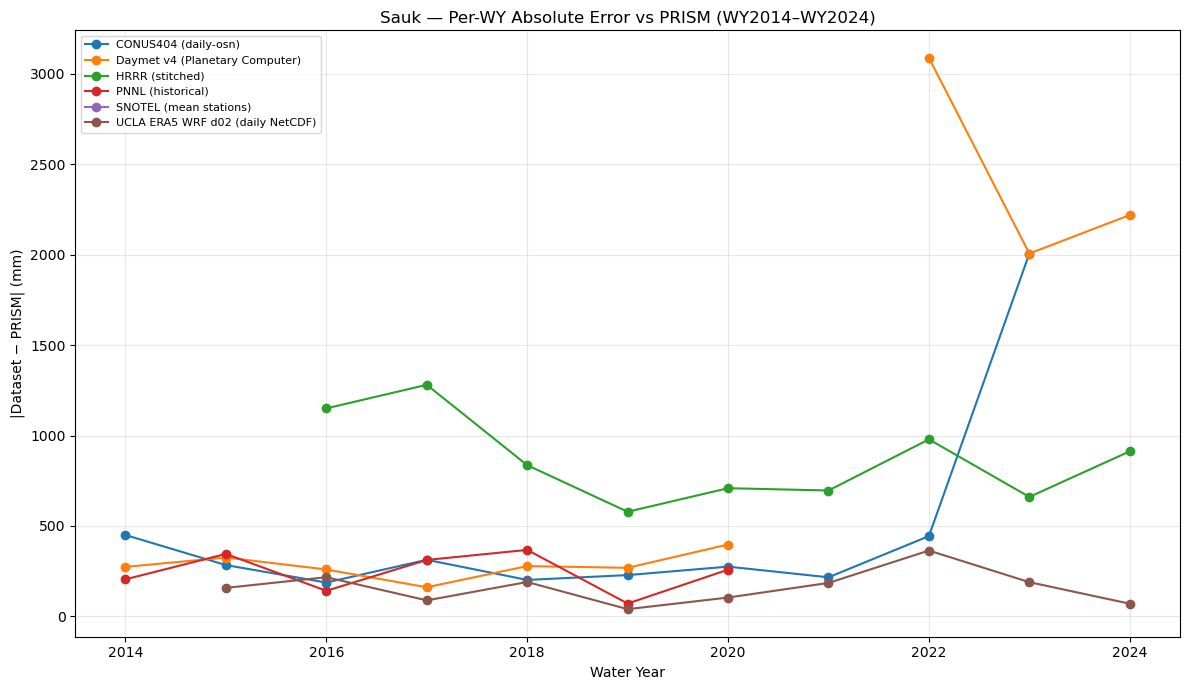

Saved MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_Lower_Skagit_2014_2024.png


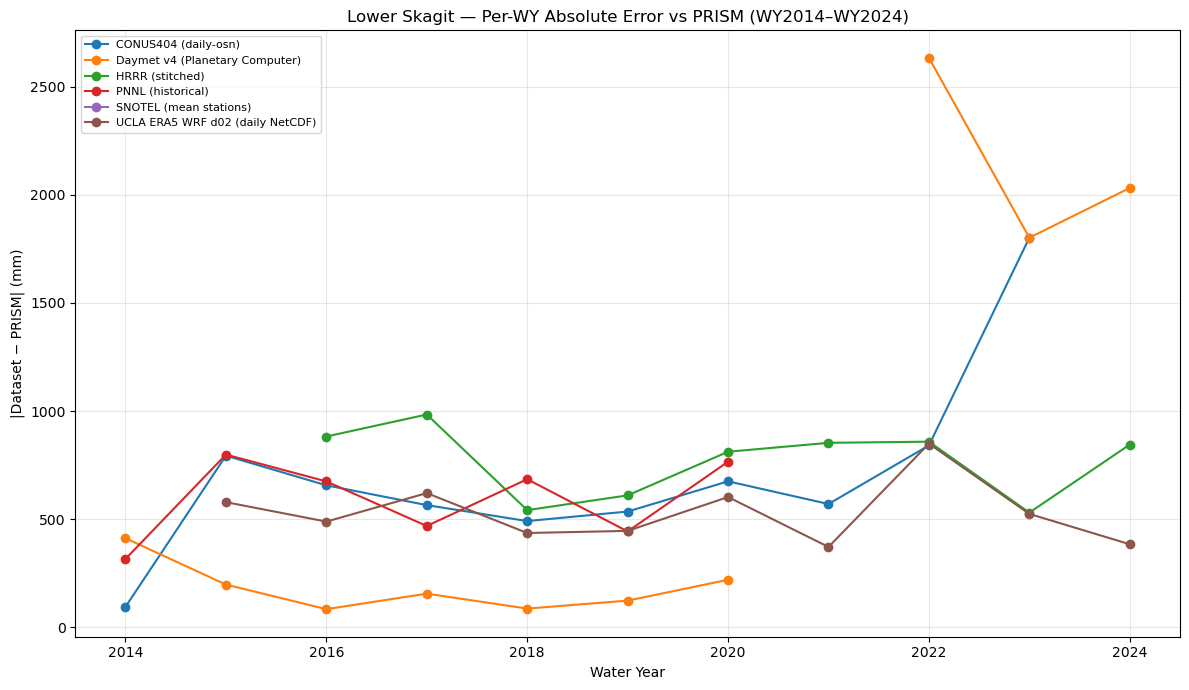

Saved combined MAE plot → /data0/balaji24/data/derived/water_year_mae_vs_PRISM_skagit_regions_2014_2024.png


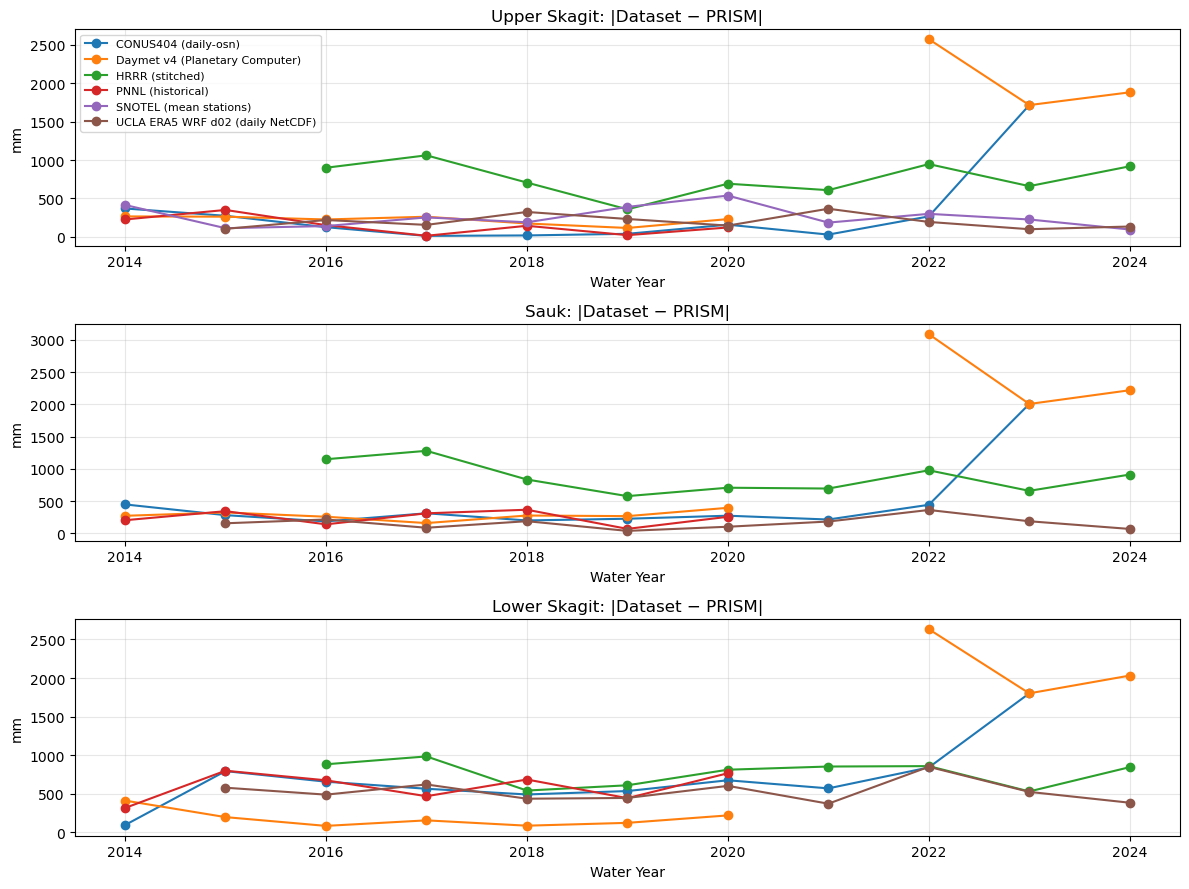

In [ ]:
# ============================
# Skagit Basin — WATER YEAR Precip (mm) by dataset (WY2014–WY2024)
# NOW BY 3 REGIONS (HUC8-dominant sub-basins):
#   - Upper Skagit
#   - Sauk
#   - Lower Skagit
#
# Safe, de-accumulating where needed, robust to duplicates
#
# WATER YEAR: Oct 1 → Sep 30, labeled by ending year
# (WY2014 = 2013-10-01..2014-09-30)
#
# INCLUDED DATASETS (if available):
# - Daymet v4 (Planetary Computer)  (replaces local ORNL)
# - PRISM (zarr)
# - HRRR (monthly zarr stitched)
# - UCLA ERA5 WRF d02 (daily NetCDF)
# - SNOTEL (egagli repo: station CSVs -> assign to regions -> mean of stations)
# - PNNL historical (hourly NetCDFs; your region mask; strict WY month completeness)
# - CONUS404 daily (HyTEST intake catalog)
#
# ADD:
# - Per-(region,WY) absolute error (|err|) vs PRISM for all other datasets
#
# PLOTTING:
# - Matplotlib, like your Code 1 style:
#   * One figure per region with WY totals
#   * Combined summary figure (3 panels, one per region)
#   * Do NOT plot 0 values (convert 0 -> NaN for plotting only)
#
# ============================

import re
import sys
import time
from pathlib import Path
from glob import glob
from urllib.parse import urlparse, urlunparse

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024  # WATER YEAR labels

# dataset roots
P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"        # many YYYY-MM_HRRR_data.zarr
PNNL_HIST   = BASE / "PNNL" / "historical" # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

CSV_OUT     = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.csv"
PNG_OUT     = OUT / f"water_year_precip_skagit_regions_{YEAR_MIN}_{YEAR_MAX}_ALL.png"

MAE_REF     = "PRISM"
MAE_CSV_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.csv"
MAE_PNG_OUT = OUT / f"water_year_mae_vs_{MAE_REF}_skagit_regions_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M","lat2d"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M","lon2d"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """Mean(da) inside each region polygon. Returns DataArray with added 'region' dimension."""
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]

    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)

    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum over water years grouped by WY label."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"]).rename("year")
    out = da.groupby(wy).sum("time", skipna=True)
    if "year" not in out.dims:
        gdim = next((d for d in out.dims if d not in ("time", "region")), None)
        if gdim:
            out = out.rename({gdim: "year"})
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        for d in ann.dims:
            if "year" in str(d):
                return float(ann.sel({d: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)
    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ==========================================================
# Daymet v4 (Planetary Computer) — WY totals by 3 regions
# ==========================================================
def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

def get_daymet_mapper():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed = pc.sign(col.assets[asset_key]).href

    u = urlparse(signed)
    base = f"{u.scheme}://{u.netloc}{u.path}"
    query = u.query
    fs = SASAppendingHTTPFileSystem(query)
    return fs.get_mapper(base)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def daymet_wy_region_total(ds_daymet, wy: int, region_name: str, geom_ll):
    t0, t1 = wy_start(wy), wy_end(wy)

    xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

    y0 = float(ds_daymet["y"].values[0])
    y1 = float(ds_daymet["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds_daymet["prcp"].sel(
        time=slice(t0, t1),
        x=slice(xmin, xmax),
        y=y_slice,
    ).chunk({"time": 92, "y": 256, "x": 256})

    key = (float(pr["x"].values[0]), float(pr["x"].values[-1]),
           float(pr["y"].values[0]), float(pr["y"].values[-1]),
           pr.sizes["x"], pr.sizes["y"], region_name)

    mask = _DAYMET_MASK_CACHE.get(key)
    if mask is None:
        xx, yy = xr.broadcast(pr["x"], pr["y"])  # dims (y,x)
        geom_xy = _daymet_project_geom_to_xy(geom_ll)
        from shapely import contains_xy
        mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
        mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
        _DAYMET_MASK_CACHE[key] = mask

    bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
    return float(bm_daily.sum(dim="time", skipna=True).compute().values)

DAYMET_NAME = "Daymet v4 (Planetary Computer)"
regions_ll = regions_gdf.to_crs("EPSG:4326")

for wy in range(YEAR_MIN, YEAR_MAX + 1):
    totals = {r: np.nan for r in REGION_NAMES}

    for attempt in range(1, 4):
        ds_daymet = None
        try:
            mapper = get_daymet_mapper()
            ds_daymet = xr.open_zarr(mapper, consolidated=True)

            if "prcp" not in ds_daymet:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            for rname in REGION_NAMES:
                geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
                totals[rname] = daymet_wy_region_total(ds_daymet, wy, rname, geom)

            break  # success

        except Exception as e:
            print(f"[DAYMET-PC] WY{wy} attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)

        finally:
            if ds_daymet is not None:
                try:
                    ds_daymet.close()
                except Exception:
                    pass

    msg = ", ".join([f"{r}={totals[r]:.1f}" for r in REGION_NAMES if np.isfinite(totals.get(r, np.nan))])
    print(f"[DAYMET-PC] WY{wy}: {msg}" if msg else f"[DAYMET-PC] WY{wy}: (no data)")

    for rname, val in totals.items():
        if np.isfinite(val):
            rows.append({"dataset": DAYMET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- PRISM (daily zarrs) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp", "pr"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                if "year" not in ann.dims or wy not in ann["year"].values:
                    continue
                for rname in ann["region"].values:
                    val = float(ann.sel(year=wy, region=rname).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- HRRR (monthly zarrs; WY-correct + SAFE concat + region masks) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    available_prefixes = sorted(list(available))
    print(f"[HRRR] months available: {available_prefixes[0]} … {available_prefixes[-1]} (n={len(available_prefixes)})")

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR] WY{wy}: missing months {missing} -> skipping WY{wy}")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for pth in parts:
            dsm = safe_open_zarr(pth)
            if var not in dsm:
                print(f"[HRRR] WY{wy}: {pth.name} missing {var} -> skipping WY{wy}")
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
        daily = hourly_mm.resample(time="1D").sum()

        rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
        rm_daily = ensure_time_sorted_unique(rm_daily)
        rm_daily = rm_daily.sel(time=slice(wy_start(wy), wy_end(wy)))

        wy_tot = rm_daily.sum("time", skipna=True)  # region
        for rname in wy_tot["region"].values:
            val = float(wy_tot.sel(region=rname).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "year": int(wy), "mm": float(val)})

        print(f"[HRRR] WY{wy}: " + ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values]))

        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass
else:
    print("[HRRR] No HRRR monthly zarrs found -> skipping HRRR.")

# ==========================================================
# UCLA ERA5 WRF d02 (daily NetCDF) — WATER YEAR, 3 regions
# ==========================================================
UCLA_DATASET_NAME = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue

        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})

        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time")
    pr_all = pr_all.sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]

        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)

        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
        print(f"[UCLA MASK] {name}: {int(mask2d.sum())} cells inside (of {mask2d.size})")

    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        t0, t1 = wy_start(wy), wy_end(wy)

        pr, parents = open_ucla_prec_for_window(t0, t1)
        if pr is None:
            continue

        try:
            units = str(pr.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                pr = pr * 1000.0
                pr.attrs["units"] = "mm"

            for rname in REGION_NAMES:
                mask = UCLA_REGION_MASKS.get(rname)
                if mask is None:
                    continue

                ts = masked_mean_timeseries(pr, mask)
                val = float(ts.sum(dim="time", skipna=True).compute().values)

                if np.isfinite(val):
                    rows.append({
                        "dataset": UCLA_DATASET_NAME,
                        "region": str(rname),
                        "year": int(wy),
                        "mm": float(val),
                    })

            try:
                msg = ", ".join([
                    f"{r}={float(masked_mean_timeseries(pr, UCLA_REGION_MASKS[r]).sum('time', skipna=True).compute().values):.1f}"
                    for r in REGION_NAMES if r in UCLA_REGION_MASKS
                ])
                print(f"[UCLA] WY{wy}: {msg}")
            except Exception:
                print(f"[UCLA] WY{wy}: computed")

        finally:
            for ds in parents:
                try: ds.close()
                except Exception: pass
else:
    print("[UCLA] Missing UCLA precip dir or coord file -> skipping UCLA.")

# ======================================================================
# SNOTEL (unchanged)
# ======================================================================
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError as e:
    print(f"[SNOTEL] Missing dependency ({e}), skipping SNOTEL.")
else:
    print("[SNOTEL] Loading stations metadata from egagli/snotel_ccss_stations...")

    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception as e:
        print(f"[SNOTEL] Failed to download stations GeoJSON: {e}")
        stations = None
    else:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

    if stations is None or stations.empty:
        print("[SNOTEL] No stations loaded, skipping.")
    else:
        skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
        inside = stations.geometry.within(skagit_geom)
        skagit_stations = stations[inside].copy()

        desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
        if not skagit_stations.empty and "name" in skagit_stations.columns:
            skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

        if skagit_stations.empty:
            print("[SNOTEL] No Skagit stations found after filtering, skipping.")
        else:
            regs = regions_gdf.copy().to_crs("EPSG:4326")
            skagit_stations = skagit_stations.to_crs("EPSG:4326")

            try:
                joined = gpd.sjoin(
                    skagit_stations,
                    regs.rename(columns={"Name": "region"}),
                    predicate="within",
                    how="left"
                )
            except TypeError:
                joined = gpd.sjoin(
                    skagit_stations,
                    regs.rename(columns={"Name": "region"}),
                    op="within",
                    how="left"
                )

            joined = joined.dropna(subset=["region"])
            if joined.empty:
                print("[SNOTEL] Stations found but none fall within the 3 regions -> skipping.")
            else:
                yearly_values = {}  # (region, wy) -> list of station totals
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                for _, row in joined.iterrows():
                    code = row.get("code")
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception as e:
                        print(f"[SNOTEL] Failed to read {code}: {e}")
                        continue

                    if "PRCPSA" not in df_s.columns:
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)

                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL (historical) — WY regional, STRICT months ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def wy_months_set(wy: int):
    return {(wy - 1, 10), (wy - 1, 11), (wy - 1, 12)} | {(wy, m) for m in range(1, 10)}

def months_present_ym(time_values):
    t = pd.to_datetime(time_values)
    return set(zip(t.year, t.month))

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        need = wy_months_set(wy)
        seen = months_present_ym(p["time"].values)
        missing = sorted(list(need - seen))
        if missing:
            dsp.close()
            continue

        P = p.sum(dim="time", skipna=True)
        spatial_dims = [d for d in P.dims if d != "time"]

        for rname in region_labels:
            mr = mask_ds["mask"].sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            mm = float(val.values)
            if np.isfinite(mm):
                rows.append({"dataset": "PNNL (historical)", "region": str(rname), "year": int(wy), "mm": float(mm)})

        dsp.close()

    mask_ds.close()

# ---------- CONUS404 (daily-osn; region masks) ----------
try:
    import intake
    import shapely
except ImportError:
    pass
else:
    print("[CONUS404] Loading from HyTEST (conus404-daily-osn)...")
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")
        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if np.isfinite(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": int(wy), "mm": float(val)})

# ---------------- Results: WY totals ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["region", "dataset", "year"])
      .reset_index(drop=True)
)

print(df)
df.to_csv(CSV_OUT, index=False)
print("Saved CSV →", CSV_OUT)

# ==========================================================
# - Remove WY2014 for UCLA
# - Remove WY2021 for Daymet
# ==========================================================
PLOT_EXCLUSIONS = {
    "UCLA ERA5 WRF d02 (daily NetCDF)": {2014},
    "Daymet v4 (Planetary Computer)": {2021},
}

df_plot = df.copy()
excl_mask = df_plot.apply(
    lambda r: int(r["year"]) in PLOT_EXCLUSIONS.get(str(r["dataset"]), set()),
    axis=1
)
df_plot.loc[excl_mask, "mm"] = np.nan

# ==========================================================
# Plotting 
# ==========================================================
for region in REGION_NAMES:
    sub = df_plot[df_plot["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mm"].astype(float).where(g["mm"].astype(float) != 0, np.nan)
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region} — Water Year Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year (Oct–Sep)")
    ax.set_ylabel("Precipitation (mm, region mean)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    out_png = OUT / f"water_year_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()

# Combined summary
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = df_plot[df_plot["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mm"].astype(float).where(g["mm"].astype(float) != 0, np.nan)
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(region)
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved combined plot →", PNG_OUT)
plt.show()

# ==========================================================
# Per-(region,WY) absolute error vs PRISM  (uses df_plot)
# ==========================================================
wide = df_plot.pivot_table(index=["region", "year"], columns="dataset", values="mm", aggfunc="first")

if MAE_REF not in wide.columns:
    raise ValueError(f"[MAE] Reference dataset '{MAE_REF}' not found. Available: {list(wide.columns)}")

abs_err = (wide.sub(wide[MAE_REF], axis=0)).abs().drop(columns=[MAE_REF], errors="ignore")

mae_long = (
    abs_err.reset_index()
           .melt(id_vars=["region", "year"], var_name="dataset", value_name="mae_mm")
           .sort_values(["region", "year", "dataset"])
           .reset_index(drop=True)
)

print("\n[MAE vs PRISM] Per (region, water year) (mm):")
print(mae_long)

mae_long.to_csv(MAE_CSV_OUT, index=False)
print("Saved MAE CSV →", MAE_CSV_OUT)

# Plot MAE: one figure per region
for region in REGION_NAMES:
    sub = mae_long[mae_long["region"] == region].copy()
    if sub.empty:
        continue

    fig = plt.figure(figsize=(12, 7))
    ax = plt.gca()

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mae_mm"].astype(float).where(g["mae_mm"].astype(float) != 0, np.nan)
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region} — Per-WY Absolute Error vs {MAE_REF} (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year")
    ax.set_ylabel(f"|Dataset − {MAE_REF}| (mm)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    out_png = OUT / f"water_year_mae_vs_{MAE_REF}_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.tight_layout()
    fig.savefig(out_png, dpi=160)
    print("Saved MAE plot →", out_png)
    plt.show()

# Combined MAE summary
fig = plt.figure(figsize=(12, 9))
for i, region in enumerate(REGION_NAMES, start=1):
    ax = plt.subplot(3, 1, i)
    sub = mae_long[mae_long["region"] == region].copy()
    if sub.empty:
        ax.set_title(f"{region} (no data)")
        ax.grid(True, alpha=0.3)
        continue

    for dsname, g in sub.groupby("dataset"):
        g = g.sort_values("year")
        y = g["mae_mm"].astype(float).where(g["mae_mm"].astype(float) != 0, np.nan)
        ax.plot(g["year"], y, marker="o", label=str(dsname))

    ax.set_title(f"{region}: |Dataset − {MAE_REF}|")
    ax.set_xlabel("Water Year")
    ax.set_ylabel("mm")
    ax.grid(True, alpha=0.3)
    if i == 1:
        ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(MAE_PNG_OUT, dpi=160)
print("Saved combined MAE plot →", MAE_PNG_OUT)
plt.show()

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x73338b3f2310>


[DAYMET-PC] WY2015 attempt 1/3 failed (ClientPayloadError): Response payload is not completed: <ContentLengthError: 400, message='Not enough data to satisfy content length header.'>. ConnectionResetError(104, 'Connection reset by peer')


Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x73319bb4d850>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x733217a06390>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x733172d15d10>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7331bc1d3a90>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7331f47bf7d0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7333ad3d1810>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x733180c4f590>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7331f4421fd0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x733172ee5610>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x733180421fd0>
Unclosed connector
connections: ['deque(

Saved plot → /data0/balaji24/data/derived/water_year_precip_SKAGIT_BASIN_2014_2024.png


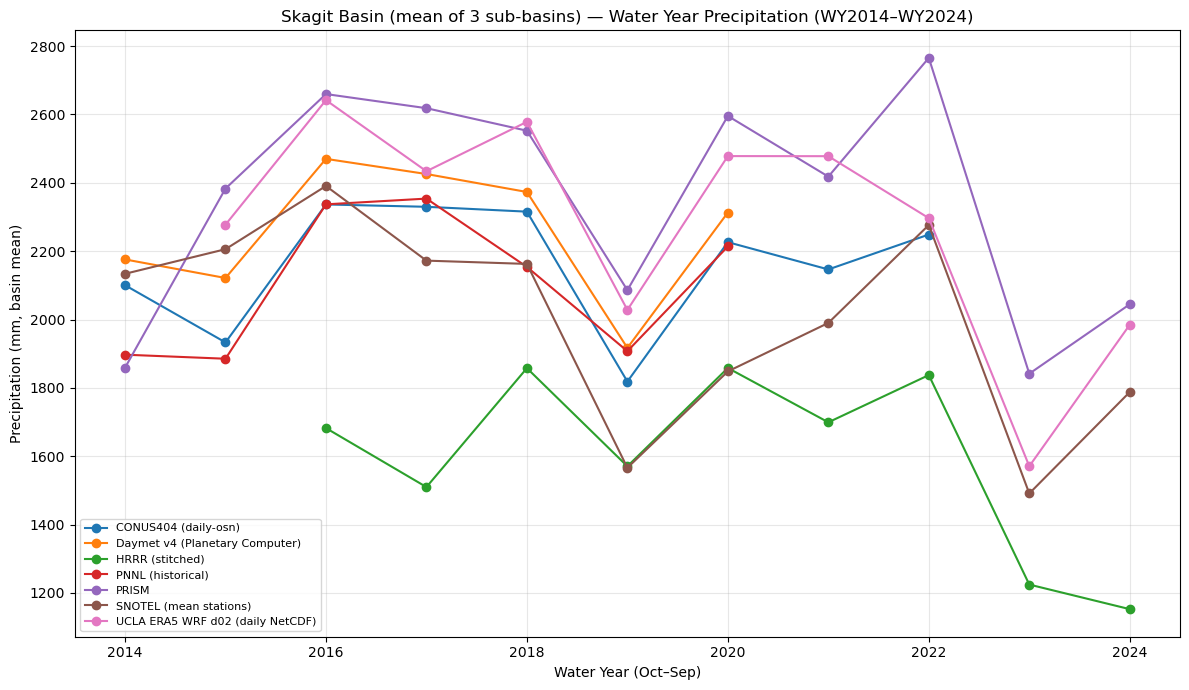

In [ ]:
# ============================
# Skagit Basin — ONE Water Year Precip graph (WY2014–WY2024)
# Output: ONE figure (single axis) showing basin-wide (3-region mean) WY totals by dataset
# - Uses the same ingest logic as full script (Daymet/PRISM/HRRR/UCLA/SNOTEL/PNNL/CONUS404)
# - Aggregation for "Skagit Basin" = mean of the 3 regional means (Upper Skagit, Sauk, Lower Skagit)
# - Do NOT plot zeros (0 -> NaN for plotting only)
# ============================

import re
import sys
import time
from pathlib import Path
from glob import glob
from urllib.parse import urlparse, urlunparse

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024  # WATER YEAR labels

# dataset roots
P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data"        # many YYYY-MM_HRRR_data.zarr
PNNL_HIST   = BASE / "PNNL" / "historical" # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

PNG_OUT = OUT / f"water_year_precip_SKAGIT_BASIN_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M","lat2d"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M","lon2d"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """Mean(da) inside each region polygon. Returns DataArray with added 'region' dimension."""
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]

    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)

    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum over water years grouped by WY label."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"]).rename("year")
    out = da.groupby(wy).sum("time", skipna=True)
    if "year" not in out.dims:
        # enforce dim rename to year if xarray used a different group dim name
        gdim = next((d for d in out.dims if d not in ("time", "region")), None)
        if gdim:
            out = out.rename({gdim: "year"})
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        for d in ann.dims:
            if "year" in str(d):
                return float(ann.sel({d: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# --------- HRRR robust deaccumulation ----------
def deaccumulate_generic(da, time_dim="time", clip_zero=True):
    run_coord = next((c for c in ("run", "init", "forecast_reference_time") if c in da.coords), None)
    step_coord = next((c for c in ("step", "lead", "forecast_hour") if c in da.coords), None)
    if run_coord and step_coord:
        dif = da.sortby([run_coord, step_coord]).diff(step_coord, label="upper")
        if clip_zero:
            dif = xr.where(dif < 0, 0, dif)
        return dif.fillna(0)
    da = da.sortby(time_dim)
    dif = da.diff(time_dim, label="upper")
    if clip_zero:
        dif = xr.where(dif < 0, 0, dif)
    return dif.fillna(0)

def hrrr_hourly_precip_mm(ds, var="tp"):
    da = ds[var]
    probe = da.isel({k: 0 for k in da.dims if k not in ("time", "step")})
    vals = probe.values
    is_cum = False
    if getattr(vals, "ndim", 0) == 1 and vals.size > 6:
        dif = np.diff(vals[:200] if vals.size > 200 else vals)
        is_cum = (dif >= -1e-6).mean() > 0.9
    return deaccumulate_generic(da, time_dim="time", clip_zero=True) if is_cum else da

def hrrr_month_prefixes_for_wy(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# Daymet v4 (Planetary Computer) — WY totals by 3 regions
# ==========================================================
def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

def get_daymet_mapper():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed = pc.sign(col.assets[asset_key]).href

    u = urlparse(signed)
    base = f"{u.scheme}://{u.netloc}{u.path}"
    query = u.query
    fs = SASAppendingHTTPFileSystem(query)
    return fs.get_mapper(base)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def daymet_wy_region_total(ds_daymet, wy: int, region_name: str, geom_ll):
    t0, t1 = wy_start(wy), wy_end(wy)

    xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

    y0 = float(ds_daymet["y"].values[0])
    y1 = float(ds_daymet["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds_daymet["prcp"].sel(
        time=slice(t0, t1),
        x=slice(xmin, xmax),
        y=y_slice,
    ).chunk({"time": 92, "y": 256, "x": 256})

    key = (float(pr["x"].values[0]), float(pr["x"].values[-1]),
           float(pr["y"].values[0]), float(pr["y"].values[-1]),
           pr.sizes["x"], pr.sizes["y"], region_name)

    mask = _DAYMET_MASK_CACHE.get(key)
    if mask is None:
        xx, yy = xr.broadcast(pr["x"], pr["y"])  # dims (y,x)
        geom_xy = _daymet_project_geom_to_xy(geom_ll)
        from shapely import contains_xy
        mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
        mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
        _DAYMET_MASK_CACHE[key] = mask

    bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
    return float(bm_daily.sum(dim="time", skipna=True).compute().values)

DAYMET_NAME = "Daymet v4 (Planetary Computer)"
regions_ll = regions_gdf.to_crs("EPSG:4326")

for wy in range(YEAR_MIN, YEAR_MAX + 1):
    totals = {r: np.nan for r in REGION_NAMES}

    for attempt in range(1, 4):
        ds_daymet = None
        try:
            mapper = get_daymet_mapper()
            ds_daymet = xr.open_zarr(mapper, consolidated=True)

            if "prcp" not in ds_daymet:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            for rname in REGION_NAMES:
                geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
                totals[rname] = daymet_wy_region_total(ds_daymet, wy, rname, geom)

            break
        except Exception as e:
            print(f"[DAYMET-PC] WY{wy} attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds_daymet is not None:
                try:
                    ds_daymet.close()
                except Exception:
                    pass

    for rname, val in totals.items():
        if np.isfinite(val):
            rows.append({"dataset": DAYMET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp", "pr"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                if "year" not in ann.dims or wy not in ann["year"].values:
                    continue
                for rname in ann["region"].values:
                    val = float(ann.sel(year=wy, region=rname).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- HRRR ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy(wy)
        if need - available:
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for pth in parts:
            dsm = safe_open_zarr(pth)
            if var not in dsm:
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")
        hourly_mm = hrrr_hourly_precip_mm(ds, var=var)
        daily = hourly_mm.resample(time="1D").sum()

        rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
        rm_daily = ensure_time_sorted_unique(rm_daily).sel(time=slice(wy_start(wy), wy_end(wy)))

        wy_tot = rm_daily.sum("time", skipna=True)  # region
        for rname in wy_tot["region"].values:
            val = float(wy_tot.sel(region=rname).values)
            if np.isfinite(val):
                rows.append({"dataset": "HRRR (stitched)", "region": str(rname), "year": int(wy), "mm": float(val)})

        for d in dsets:
            try: d.close()
            except Exception: pass
        try: ds0.close()
        except Exception: pass

# ---------- UCLA ----------
UCLA_DATASET_NAME  = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time").sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]
        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)
        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        if wy == 2014:
            continue

        t0, t1 = wy_start(wy), wy_end(wy)
        pr, parents = open_ucla_prec_for_window(t0, t1)
        if pr is None:
            continue
        try:
            units = str(pr.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                pr = pr * 1000.0
                pr.attrs["units"] = "mm"

            for rname in REGION_NAMES:
                mask = UCLA_REGION_MASKS.get(rname)
                if mask is None:
                    continue
                ts = masked_mean_timeseries(pr, mask)
                val = float(ts.sum(dim="time", skipna=True).compute().values)
                if np.isfinite(val):
                    rows.append({"dataset": UCLA_DATASET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})
        finally:
            for ds in parents:
                try: ds.close()
                except Exception: pass

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError:
    pass
else:
    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception:
        gj = None

    if gj:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

        if stations is not None and not stations.empty:
            skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
            skagit_stations = stations[stations.geometry.within(skagit_geom)].copy()

            desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
            if not skagit_stations.empty and "name" in skagit_stations.columns:
                skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

            if not skagit_stations.empty:
                regs = regions_gdf.copy().to_crs("EPSG:4326")
                skagit_stations = skagit_stations.to_crs("EPSG:4326")

                try:
                    joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name": "region"}), predicate="within", how="left")
                except TypeError:
                    joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name": "region"}), op="within", how="left")

                joined = joined.dropna(subset=["region"])
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                yearly_values = {}  # (region, wy) -> list of station totals
                for _, row in joined.iterrows():
                    code = row.get("code")
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception:
                        continue
                    if "PRCPSA" not in df_s.columns:
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)
                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def wy_months_set(wy: int):
    return {(wy - 1, 10), (wy - 1, 11), (wy - 1, 12)} | {(wy, m) for m in range(1, 10)}

def months_present_ym(time_values):
    t = pd.to_datetime(time_values)
    return set(zip(t.year, t.month))

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        need = wy_months_set(wy)
        seen = months_present_ym(p["time"].values)
        if need - seen:
            dsp.close()
            continue

        P = p.sum(dim="time", skipna=True)
        spatial_dims = [d for d in P.dims if d != "time"]

        for rname in region_labels:
            mr = mask_ds["mask"].sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            mm = float(val.values)
            if np.isfinite(mm):
                rows.append({"dataset": "PNNL (historical)", "region": str(rname), "year": int(wy), "mm": float(mm)})

        dsp.close()

    mask_ds.close()

# ---------- CONUS404 ----------
try:
    import intake
    import shapely
except ImportError:
    pass
else:
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")
        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if np.isfinite(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": int(wy), "mm": float(val)})

# ---------------- Build DF ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["dataset", "region", "year"])
      .reset_index(drop=True)
)

# ============================
# ONE GRAPH: Skagit Basin = mean of 3 regions
# ============================
basin = (
    df.groupby(["dataset", "year"], as_index=False)["mm"]
      .mean()  # mean across regions (each row already region-mean mm)
      .sort_values(["dataset", "year"])
)

PLOT_EXCLUSIONS = {
    "UCLA ERA5 WRF d02 (daily NetCDF)": {2014},
    "Daymet v4 (Planetary Computer)": {2021},
}
basin_plot = basin.copy()
mask_excl = basin_plot.apply(
    lambda r: int(r["year"]) in PLOT_EXCLUSIONS.get(str(r["dataset"]), set()),
    axis=1
)
basin_plot.loc[mask_excl, "mm"] = np.nan

# ============================
# Plot (single axis)
# ============================
fig = plt.figure(figsize=(12, 7))
ax = plt.gca()

for dsname, g in basin_plot.groupby("dataset"):
    g = g.sort_values("year")
    y = g["mm"].astype(float).where(g["mm"].astype(float) != 0, np.nan)
    ax.plot(g["year"], y, marker="o", label=str(dsname))

ax.set_title(f"Skagit Basin (mean of 3 sub-basins) — Water Year Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
ax.set_xlabel("Water Year (Oct–Sep)")
ax.set_ylabel("Precipitation (mm, basin mean)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

ERROR 1: PROJ: proj_create_from_database: Open of /home/balaji24/skagit-met/.pixi/envs/analysis/share/proj failed
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x73778960ec50>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7377889890d0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x73777c48b250>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x73777c5e9b00>, 956334.150009562), (<aiohttp.client_proto.ResponseHandler object at 0x73777c4fbf50>, 956335.633122534)])']
connector: <aiohttp.connector.TCPConnector object at 0x73777c5cf110>
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL

[HRRR f06] Found 126 monthly zarrs. Range: 2014-07 .. 2024-12
[HRRR f06] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06'] -> skipping
[HRRR f06] WY2015: Upper Skagit=1563.9, Sauk=1695.8, Lower Skagit=1520.6
[HRRR f06] WY2016: Upper Skagit=1827.4, Sauk=2060.8, Lower Skagit=1886.0
[HRRR f06] WY2017: Upper Skagit=1662.5, Sauk=1868.6, Lower Skagit=1695.0
[HRRR f06] WY2018: Upper Skagit=1821.5, Sauk=2188.9, Lower Skagit=1979.3
[HRRR f06] WY2019: Upper Skagit=1796.1, Sauk=1914.7, Lower Skagit=1594.8


Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

[HRRR f06] WY2020: Upper Skagit=1850.7, Sauk=2396.9, Lower Skagit=1757.5
[HRRR f06] WY2021: Upper Skagit=1777.2, Sauk=2194.5, Lower Skagit=1727.5
[HRRR f06] WY2022: Upper Skagit=1996.3, Sauk=2347.9, Lower Skagit=1892.4
[HRRR f06] WY2023: Upper Skagit=1285.1, Sauk=1540.5, Lower Skagit=1324.7
[HRRR f06] WY2024: Upper Skagit=1417.7, Sauk=1727.1, Lower Skagit=1528.0
                 dataset        region  year           mm
0   CONUS404 (daily-osn)  Lower Skagit  2014  1706.416138
1   CONUS404 (daily-osn)  Lower Skagit  2015  1577.229980
2   CONUS404 (daily-osn)  Lower Skagit  2016  1859.286377
3   CONUS404 (daily-osn)  Lower Skagit  2017  1997.960693
4   CONUS404 (daily-osn)  Lower Skagit  2018  1975.785767
5   CONUS404 (daily-osn)  Lower Skagit  2019  1517.009399
6   CONUS404 (daily-osn)  Lower Skagit  2020  1881.061890
7   CONUS404 (daily-osn)  Lower Skagit  2021  1799.353516
8   CONUS404 (daily-osn)  Lower Skagit  2022  1792.069824
9   CONUS404 (daily-osn)  Lower Skagit  2023     0.0000

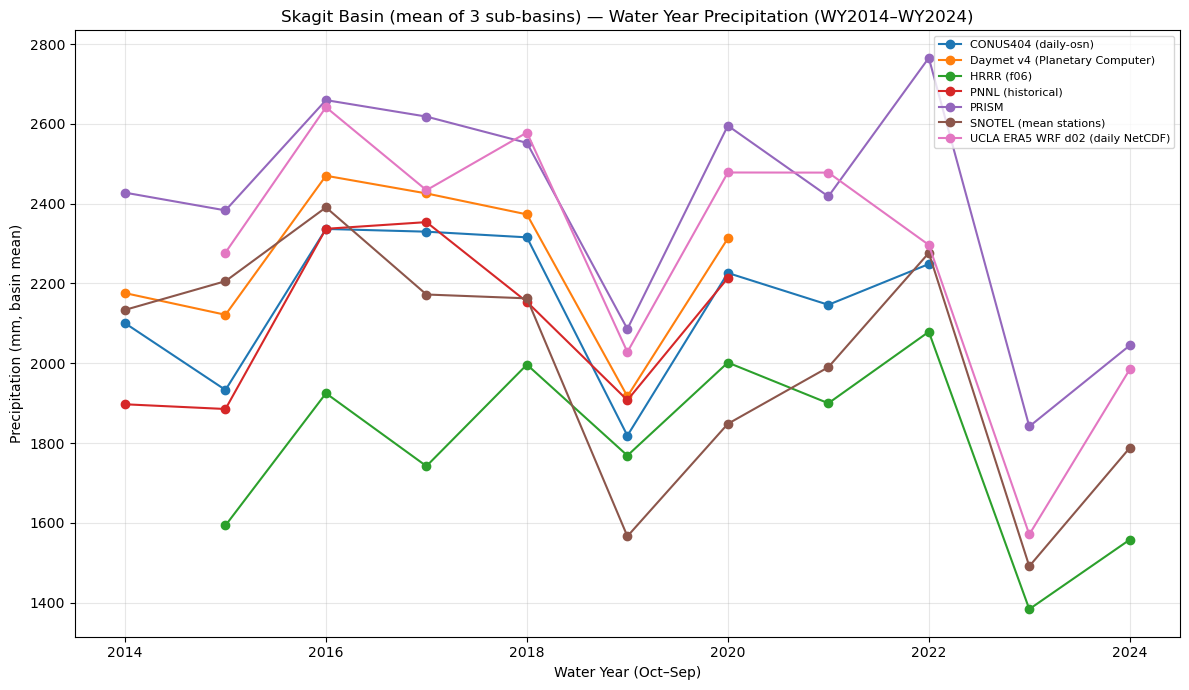

In [ ]:
# ============================
# Skagit Basin — ONE Water Year Precip graph (WY2014–WY2024)
# Output: ONE figure (single axis) showing basin-wide (3-region mean) WY totals by dataset
#
# HRRR FIX:
#   - Uses HRRR f06 zarrs (e.g., YYYY-MM_HRRR_f06_data.zarr)
#   - Treats tp as 6-hour accumulation for valid time = init + 6h
#   - Keeps only init hours 00/06/12/18 (non-overlapping windows)
#   - Shifts time +6h to valid time
#   - Daily totals = sum of the 4 six-hour windows per day
#
# ============================

import re
import sys
import time
from pathlib import Path
from glob import glob
from urllib.parse import urlparse, urlunparse

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024  # WATER YEAR labels

# dataset roots
P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data_06"     # NEW HRRR f06 zarrs live here
PNNL_HIST   = BASE / "PNNL" / "historical" # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

PNG_OUT = OUT / f"water_year_precip_SKAGIT_BASIN_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M","lat2d"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M","lon2d"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """Mean(da) inside each region polygon. Returns DataArray with added 'region' dimension."""
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]

    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)

    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum over water years grouped by WY label."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"]).rename("year")
    out = da.groupby(wy).sum("time", skipna=True)
    if "year" not in out.dims:
        gdim = next((d for d in out.dims if d not in ("time", "region")), None)
        if gdim:
            out = out.rename({gdim: "year"})
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        for d in ann.dims:
            if "year" in str(d):
                return float(ann.sel({d: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# ============================
# HRRR f06-specific logic
# ============================
def hrrr_f06_daily_precip_mm(ds: xr.Dataset, var="tp") -> xr.DataArray:
    """
    Correct HRRR f06 logic for tp:
      - ds.time is INIT time
      - keep only init hours 00/06/12/18 (non-overlapping 6h blocks)
      - shift init -> valid time by +6h
      - daily totals = sum of 6h accumulations per day
    """
    if var not in ds:
        raise ValueError(f"[HRRR f06] Missing {var}. vars={list(ds.data_vars)}")

    da = ensure_time_sorted_unique(ds[var])

    t = pd.to_datetime(da["time"].values)
    keep = np.isin(t.hour, [0, 6, 12, 18])
    da = da.sel(time=da["time"].values[keep])

    # shift init -> valid
    da = da.assign_coords(time=(pd.to_datetime(da["time"].values) + pd.Timedelta(hours=6)))

    # daily totals
    daily = da.resample(time="1D").sum()
    return daily

def hrrr_month_prefixes_for_wy_f06(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# Daymet v4 (Planetary Computer) — WY totals by 3 regions
# ==========================================================
def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

def get_daymet_mapper():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed = pc.sign(col.assets[asset_key]).href

    u = urlparse(signed)
    base = f"{u.scheme}://{u.netloc}{u.path}"
    query = u.query
    fs = SASAppendingHTTPFileSystem(query)
    return fs.get_mapper(base)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def daymet_wy_region_total(ds_daymet, wy: int, region_name: str, geom_ll):
    t0, t1 = wy_start(wy), wy_end(wy)

    xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

    y0 = float(ds_daymet["y"].values[0])
    y1 = float(ds_daymet["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds_daymet["prcp"].sel(
        time=slice(t0, t1),
        x=slice(xmin, xmax),
        y=y_slice,
    ).chunk({"time": 92, "y": 256, "x": 256})

    key = (float(pr["x"].values[0]), float(pr["x"].values[-1]),
           float(pr["y"].values[0]), float(pr["y"].values[-1]),
           pr.sizes["x"], pr.sizes["y"], region_name)

    mask = _DAYMET_MASK_CACHE.get(key)
    if mask is None:
        xx, yy = xr.broadcast(pr["x"], pr["y"])  # dims (y,x)
        geom_xy = _daymet_project_geom_to_xy(geom_ll)
        from shapely import contains_xy
        mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
        mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
        _DAYMET_MASK_CACHE[key] = mask

    bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
    return float(bm_daily.sum(dim="time", skipna=True).compute().values)

DAYMET_NAME = "Daymet v4 (Planetary Computer)"
regions_ll = regions_gdf.to_crs("EPSG:4326")

for wy in range(YEAR_MIN, YEAR_MAX + 1):
    totals = {r: np.nan for r in REGION_NAMES}

    for attempt in range(1, 4):
        ds_daymet = None
        try:
            mapper = get_daymet_mapper()
            ds_daymet = xr.open_zarr(mapper, consolidated=True)

            if "prcp" not in ds_daymet:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            for rname in REGION_NAMES:
                geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
                totals[rname] = daymet_wy_region_total(ds_daymet, wy, rname, geom)

            break
        except Exception as e:
            print(f"[DAYMET-PC] WY{wy} attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds_daymet is not None:
                try:
                    ds_daymet.close()
                except Exception:
                    pass

    for rname, val in totals.items():
        if np.isfinite(val):
            rows.append({"dataset": DAYMET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- PRISM ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp", "pr"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                if "year" not in ann.dims or wy not in ann["year"].values:
                    continue
                for rname in ann["region"].values:
                    val = float(ann.sel(year=wy, region=rname).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- HRRR (f06) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_f06_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    print(f"[HRRR f06] Found {len(monthly)} monthly zarrs. Range: {sorted(list(available))[0]} .. {sorted(list(available))[-1]}")
    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy_f06(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR f06] WY{wy}: missing months {missing} -> skipping")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR f06] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for pth in parts:
            dsm = safe_open_zarr(pth)
            if var not in dsm:
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        try:
            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            # correct f06 daily totals
            daily = hrrr_f06_daily_precip_mm(ds, var=var)

            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily).sel(time=slice(wy_start(wy), wy_end(wy)))

            wy_tot = rm_daily.sum("time", skipna=True)  # region
            for rname in wy_tot["region"].values:
                val = float(wy_tot.sel(region=rname).values)
                if np.isfinite(val):
                    rows.append({"dataset": "HRRR (f06)", "region": str(rname), "year": int(wy), "mm": float(val)})

            print(f"[HRRR f06] WY{wy}: " + ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values]))
        finally:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print(f"[HRRR f06] No HRRR f06 zarrs found under {P_HRRR_DIR} -> skipping HRRR.")

# ---------- UCLA ----------
UCLA_DATASET_NAME  = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time").sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]
        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)
        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        if wy == 2014:
            continue

        t0, t1 = wy_start(wy), wy_end(wy)
        pr, parents = open_ucla_prec_for_window(t0, t1)
        if pr is None:
            continue
        try:
            units = str(pr.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                pr = pr * 1000.0
                pr.attrs["units"] = "mm"

            for rname in REGION_NAMES:
                mask = UCLA_REGION_MASKS.get(rname)
                if mask is None:
                    continue
                ts = masked_mean_timeseries(pr, mask)
                val = float(ts.sum(dim="time", skipna=True).compute().values)
                if np.isfinite(val):
                    rows.append({"dataset": UCLA_DATASET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})
        finally:
            for ds in parents:
                try: ds.close()
                except Exception: pass

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError:
    pass
else:
    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception:
        gj = None

    if gj:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

        if stations is not None and not stations.empty:
            skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
            skagit_stations = stations[stations.geometry.within(skagit_geom)].copy()

            desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
            if not skagit_stations.empty and "name" in skagit_stations.columns:
                skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

            if not skagit_stations.empty:
                regs = regions_gdf.copy().to_crs("EPSG:4326")
                skagit_stations = skagit_stations.to_crs("EPSG:4326")

                try:
                    joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name": "region"}), predicate="within", how="left")
                except TypeError:
                    joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name": "region"}), op="within", how="left")

                joined = joined.dropna(subset=["region"])
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                yearly_values = {}  # (region, wy) -> list of station totals
                for _, row in joined.iterrows():
                    code = row.get("code")
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception:
                        continue
                    if "PRCPSA" not in df_s.columns:
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)
                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def wy_months_set(wy: int):
    return {(wy - 1, 10), (wy - 1, 11), (wy - 1, 12)} | {(wy, m) for m in range(1, 10)}

def months_present_ym(time_values):
    t = pd.to_datetime(time_values)
    return set(zip(t.year, t.month))

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        need = wy_months_set(wy)
        seen = months_present_ym(p["time"].values)
        if need - seen:
            dsp.close()
            continue

        P = p.sum(dim="time", skipna=True)
        spatial_dims = [d for d in P.dims if d != "time"]

        for rname in region_labels:
            mr = mask_ds["mask"].sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            mm = float(val.values)
            if np.isfinite(mm):
                rows.append({"dataset": "PNNL (historical)", "region": str(rname), "year": int(wy), "mm": float(mm)})

        dsp.close()

    mask_ds.close()

# ---------- CONUS404 ----------
try:
    import intake
    import shapely
except ImportError:
    pass
else:
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")
        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if np.isfinite(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": int(wy), "mm": float(val)})

# ---------------- Build DF ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["dataset", "region", "year"])
      .reset_index(drop=True)
)

print(df.head(30))
print(f"\nRows: {len(df)}")

# ============================
# ONE GRAPH: Skagit Basin = mean of 3 regions
# ============================
basin = (
    df.groupby(["dataset", "year"], as_index=False)["mm"]
      .mean()
      .sort_values(["dataset", "year"])
)

PLOT_EXCLUSIONS = {
    "UCLA ERA5 WRF d02 (daily NetCDF)": {2014},
    "Daymet v4 (Planetary Computer)": {2021},
}
basin_plot = basin.copy()
mask_excl = basin_plot.apply(
    lambda r: int(r["year"]) in PLOT_EXCLUSIONS.get(str(r["dataset"]), set()),
    axis=1
)
basin_plot.loc[mask_excl, "mm"] = np.nan

# ============================
# Plot (single axis)
# ============================
fig = plt.figure(figsize=(12, 7))
ax = plt.gca()

for dsname, g in basin_plot.groupby("dataset"):
    g = g.sort_values("year")
    y = g["mm"].astype(float).where(g["mm"].astype(float) != 0, np.nan)
    ax.plot(g["year"], y, marker="o", label=str(dsname))

ax.set_title(f"Skagit Basin (mean of 3 sub-basins) — Water Year Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
ax.set_xlabel("Water Year (Oct–Sep)")
ax.set_ylabel("Precipitation (mm, basin mean)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()

Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b50827b72c0>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b508283a840>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b508d532420>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b5080471f70>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b5080470980>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b50804d0830>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b50804b3e60>
Unclosed client session
client_session: <aiohttp.client.ClientSession object at 0x7b508d517f50>
Unclosed connector
connections: ['deque([(<aiohttp.client_proto.ResponseHandler object at 0x7b50801f50d0>, 979431.312866069)])']
connector: <aiohttp.connector.TCPConnector object at 0x7b5080398b90>
Unclosed client session
client_ses

[HRRR f06] Found 126 monthly zarrs. Range: 2014-07 .. 2024-12
[HRRR f06] WY2014: missing months ['2013-10', '2013-11', '2013-12', '2014-01', '2014-02', '2014-03', '2014-04', '2014-05', '2014-06'] -> skipping


Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed out
Future exception was never retrieved
future: <Future finished exception=ClientConnectionError('Connection lost: SSL shutdown timed out')>
TimeoutError: SSL shutdown timed out

The above exception was the direct cause of the following exception:

aiohttp.client_exceptions.ClientConnectionError: Connection lost: SSL shutdown timed

[HRRR f06] WY2015: Upper Skagit=1563.9, Sauk=1695.8, Lower Skagit=1520.6
[HRRR f06] WY2016: Upper Skagit=1827.4, Sauk=2060.8, Lower Skagit=1886.0
[HRRR f06] WY2017: Upper Skagit=1662.5, Sauk=1868.6, Lower Skagit=1695.0
[HRRR f06] WY2018: Upper Skagit=1821.5, Sauk=2188.9, Lower Skagit=1979.3
[HRRR f06] WY2019: Upper Skagit=1796.1, Sauk=1914.7, Lower Skagit=1594.8
[HRRR f06] WY2020: Upper Skagit=1850.7, Sauk=2396.9, Lower Skagit=1757.5
[HRRR f06] WY2021: Upper Skagit=1777.2, Sauk=2194.5, Lower Skagit=1727.5
[HRRR f06] WY2022: Upper Skagit=1996.3, Sauk=2347.9, Lower Skagit=1892.4
[HRRR f06] WY2023: Upper Skagit=1285.1, Sauk=1540.5, Lower Skagit=1324.7
[HRRR f06] WY2024: Upper Skagit=1417.7, Sauk=1727.1, Lower Skagit=1528.0
                 dataset        region  year           mm
0   CONUS404 (daily-osn)  Lower Skagit  2014  1706.416016
1   CONUS404 (daily-osn)  Lower Skagit  2015  1577.230103
2   CONUS404 (daily-osn)  Lower Skagit  2016  1859.286499
3   CONUS404 (daily-osn)  Lower Skagit

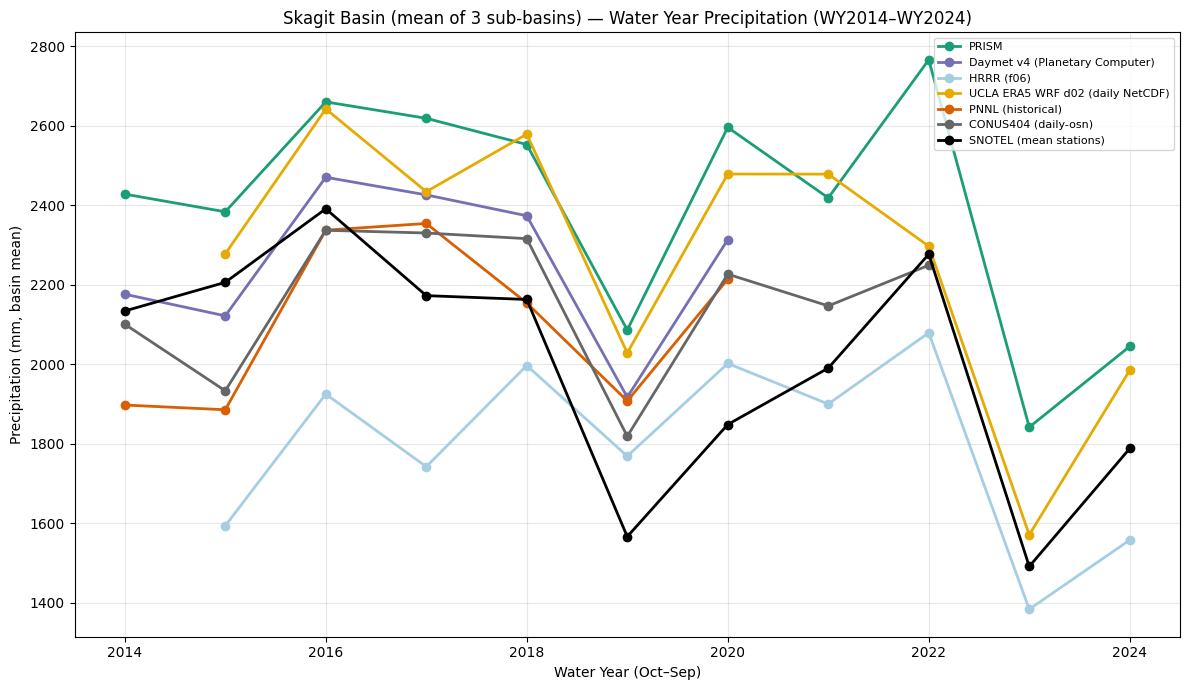

In [ ]:
# ============================
# Skagit Basin — ONE Water Year Precip graph (WY2014–WY2024)
# Output: ONE figure (single axis) showing basin-wide (3-region mean) WY totals by dataset
#
# HRRR FIX:
#   - Uses HRRR f06 zarrs (e.g., YYYY-MM_HRRR_f06_data.zarr)
#   - Treats tp as 6-hour accumulation for valid time = init + 6h
#   - Keeps only init hours 00/06/12/18 (non-overlapping windows)
#   - Shifts time +6h to valid time
#   - Daily totals = sum of the 4 six-hour windows per day
#
# - Uses the SAME canonical color codes as your event-cumulative script
# - Stable dataset plotting order
# ============================

import re
import sys
import time
from pathlib import Path
from glob import glob
from urllib.parse import urlparse, urlunparse

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024  # WATER YEAR labels

# dataset roots
P_PRISM_DIR = BASE / "prism_ppt"
P_HRRR_DIR  = BASE / "weather_data_06"     # HRRR f06 zarrs live here
PNNL_HIST   = BASE / "PNNL" / "historical" # hourly NetCDFs per year

OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

PNG_OUT = OUT / f"water_year_precip_SKAGIT_BASIN_{YEAR_MIN}_{YEAR_MAX}.png"

REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

# ============================================================
# CANONICAL COLORS 
# ============================================================
DATASET_ORDER = [
    "PRISM 4km",
    "PRISM 800m",
    "Daymet-PC",
    "HRRR F01",
    "HRRR F06",
    "UCLA ERA5 d02",
    "PNNL hist",
    "CONUS404",
    "SNOTEL (mean stations)",
]

COLORS = {
    # PRISM family (greens)
    "PRISM 4km":     "#1B9E77",
    "PRISM 800m":    "#66C2A5",

    # Daymet (purple)
    "Daymet-PC":     "#7570B3",

    # HRRR family (blues)
    "HRRR F01":      "#1F78B4",
    "HRRR F06":      "#A6CEE3",

    # UCLA ERA5 d02 (orange)
    "UCLA ERA5 d02": "#E6AB02",

    # PNNL hist (red)
    "PNNL hist":     "#D95F02",

    # CONUS404 (gray)
    "CONUS404":      "#666666",

    # SNOTEL (black)
    "SNOTEL (mean stations)": "#000000",
}

def canonical_label(dsname: str) -> str:
    """Map this script's dataset names -> your canonical palette keys."""
    s = str(dsname)

    # PRISM in this script is stored as "PRISM" (4km zarrs)
    if s == "PRISM":
        return "PRISM 4km"

    # Daymet name in this script
    if "Daymet v4" in s or "Planetary Computer" in s:
        return "Daymet-PC"

    # HRRR name in this script
    if "HRRR" in s and "f06" in s.lower():
        return "HRRR F06"
    if "HRRR" in s and "f01" in s.lower():
        return "HRRR F01"

    # UCLA name in this script
    if "UCLA" in s and "d02" in s:
        return "UCLA ERA5 d02"

    # PNNL name in this script
    if s.startswith("PNNL"):
        return "PNNL hist"

    # CONUS404 name in this script
    if s.startswith("CONUS404"):
        return "CONUS404"

    # SNOTEL already matches
    if s.startswith("SNOTEL"):
        return "SNOTEL (mean stations)"

    return s  # fallback

# ---------------- Helpers ----------------
def safe_open_zarr(p: Path):
    try:
        return xr.open_zarr(p, consolidated=True)
    except Exception:
        return xr.open_zarr(p, consolidated=False)

def find_lat_lon_names(ds):
    lat_name = next((n for n in ["lat","latitude","XLAT","XLAT_M","lat2d"] if n in ds), None)
    lon_name = next((n for n in ["lon","longitude","XLONG","XLONG_M","lon2d"] if n in ds), None)
    return lat_name, lon_name

def ensure_time_sorted_unique(da):
    if "time" not in da.dims:
        return da
    da = da.sortby("time")
    try:
        t = pd.to_datetime(da["time"].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel(time=np.sort(idx))
    except Exception:
        pass
    return da

# ---------------- Region handling ----------------
def load_regions_gdf():
    """Load the 3 dominant HUC8 polygons, clipped to Skagit boundary."""
    import geopandas as gpd

    skagit_gdf = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
    huc8 = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

    # NOTE: this assumes the HUC8 file has a 'Name' column matching REGION_NAMES
    huc8_3 = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
    if huc8_3.empty:
        raise ValueError(
            f"No matching HUC8 regions found for {REGION_NAMES}. "
            f"Check HUC8_GEO path and the 'Name' field values."
        )

    huc8_3 = gpd.overlay(huc8_3, skagit_gdf, how="intersection")
    regions_gdf = huc8_3[["Name", "geometry"]].reset_index(drop=True)

    regions_gdf["Name"] = pd.Categorical(regions_gdf["Name"], categories=REGION_NAMES, ordered=True)
    regions_gdf = regions_gdf.sort_values("Name").reset_index(drop=True)
    return regions_gdf

def _to_2d(arr):
    if "time" in arr.dims:
        arr = arr.isel(time=0)
    for d in list(arr.dims):
        if arr.sizes[d] == 1:
            arr = arr.isel({d: 0})
    while arr.ndim > 2:
        extra = [d for d in arr.dims if d not in ("x","y","lon","lat")]
        if not extra:
            break
        arr = arr.isel({extra[0]: 0})
    return arr

def region_mean(da, grid_ds=None, regions_gdf=None):
    """Mean(da) inside each region polygon. Returns DataArray with added 'region' dimension."""
    if regions_gdf is None:
        raise ValueError("regions_gdf is required for region_mean")

    try:
        import regionmask
    except Exception as e:
        raise RuntimeError(f"regionmask is required for region_mean: {e}")

    time_dim = "time" if "time" in da.dims else None
    spatial = [d for d in da.dims if d != time_dim]

    if not spatial:
        out = da
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    host = grid_ds if grid_ds is not None else da.to_dataset(name="_tmp")
    lat_name, lon_name = find_lat_lon_names(host)

    if not (lat_name and lon_name):
        out = da.mean(spatial, skipna=True)
        return out.expand_dims(region=list(regions_gdf["Name"].values))

    lon = _to_2d(host[lon_name])
    lat = _to_2d(host[lat_name])

    regs = regionmask.Regions(
        outlines=list(regions_gdf.geometry.values),
        names=list(regions_gdf["Name"].astype(str).values),
        numbers=list(range(len(regions_gdf))),
        name="Skagit_3HUC8",
    )
    rid = regs.mask(lon, lat)

    out_list = []
    for i, _rname in enumerate(regs.names):
        m = (rid == i)
        w = xr.where(m, 1.0, np.nan)
        out_list.append((da * w).mean(spatial, skipna=True))

    out = xr.concat(out_list, dim="region")
    out = out.assign_coords(region=regs.names)
    return out

# ---------------- WATER YEAR helpers ----------------
def wy_start(wy: int) -> str:
    return f"{wy-1}-10-01"

def wy_end(wy: int) -> str:
    return f"{wy}-09-30"

def water_year_index(time_da):
    return xr.where(time_da.dt.month >= 10, time_da.dt.year + 1, time_da.dt.year)

def water_year_sum_mm(da):
    """Sum over water years grouped by WY label."""
    if "time" not in da.dims:
        out = xr.DataArray(da).rename("mm")
        return out
    da = ensure_time_sorted_unique(da)
    wy = water_year_index(da["time"]).rename("year")
    out = da.groupby(wy).sum("time", skipna=True)
    if "year" not in out.dims:
        gdim = next((d for d in out.dims if d not in ("time", "region")), None)
        if gdim:
            out = out.rename({gdim: "year"})
    out.name = "mm"
    return out

def pick_wy(ann, wy):
    try:
        if "year" in ann.coords:
            return float(ann.sel(year=wy).values)
        for c in ann.coords:
            if "year" in str(c):
                return float(ann.sel({c: wy}).values)
        for d in ann.dims:
            if "year" in str(d):
                return float(ann.sel({d: wy}).values)
        return float(ann.values.item())
    except Exception:
        return np.nan

# ============================
# HRRR f06-specific logic
# ============================
def hrrr_f06_daily_precip_mm(ds: xr.Dataset, var="tp") -> xr.DataArray:
    """
    Correct HRRR f06 logic for tp:
      - ds.time is INIT time
      - keep only init hours 00/06/12/18 (non-overlapping 6h blocks)
      - shift init -> valid time by +6h
      - daily totals = sum of 6h accumulations per day
    """
    if var not in ds:
        raise ValueError(f"[HRRR f06] Missing {var}. vars={list(ds.data_vars)}")

    da = ensure_time_sorted_unique(ds[var])

    t = pd.to_datetime(da["time"].values)
    keep = np.isin(t.hour, [0, 6, 12, 18])
    da = da.sel(time=da["time"].values[keep])

    # shift init -> valid
    da = da.assign_coords(time=(pd.to_datetime(da["time"].values) + pd.Timedelta(hours=6)))

    # daily totals
    daily = da.resample(time="1D").sum()
    return daily

def hrrr_month_prefixes_for_wy_f06(wy: int):
    prev = wy - 1
    prefixes = [f"{prev}-10", f"{prev}-11", f"{prev}-12"]
    prefixes += [f"{wy}-{m:02d}" for m in range(1, 10)]
    return set(prefixes)

# ---------------- Collectors ----------------
regions_gdf = load_regions_gdf()
rows = []

# ==========================================================
# Daymet v4 (Planetary Computer) — WY totals by 3 regions
# ==========================================================
def ensure_daymet_pkgs():
    needed = ["pystac-client", "planetary-computer", "pyproj", "fsspec", "zarr"]
    import importlib, subprocess
    missing = []
    for p in needed:
        mod = p.replace("-", "_")
        try:
            importlib.import_module(mod)
        except Exception:
            missing.append(p)
    if missing:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

ensure_daymet_pkgs()

from pystac_client import Client
import planetary_computer as pc
from pyproj import CRS, Transformer
from fsspec.implementations.http import HTTPFileSystem
from shapely.ops import transform as shp_transform

class SASAppendingHTTPFileSystem(HTTPFileSystem):
    def __init__(self, query: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self._fixed_query = query.lstrip("?")

    def _with_query(self, url: str) -> str:
        u = urlparse(url)
        q = u.query or self._fixed_query
        return urlunparse((u.scheme, u.netloc, u.path, u.params, q, u.fragment))

    def _open(self, path, mode="rb", block_size=None, **kwargs):
        return super()._open(self._with_query(path), mode=mode, block_size=block_size, **kwargs)

    async def _cat_file(self, url, start=None, end=None, **kwargs):
        return await super()._cat_file(self._with_query(url), start=start, end=end, **kwargs)

def get_daymet_mapper():
    stac = Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    col = stac.get_collection("daymet-daily-na")
    asset_key = "zarr-https" if "zarr-https" in col.assets else "zarr-abfs"
    signed = pc.sign(col.assets[asset_key]).href

    u = urlparse(signed)
    base = f"{u.scheme}://{u.netloc}{u.path}"
    query = u.query
    fs = SASAppendingHTTPFileSystem(query)
    return fs.get_mapper(base)

def daymet_lcc_crs():
    return CRS.from_proj4(
        "+proj=lcc +lat_1=25 +lat_2=60 +lat_0=42.5 +lon_0=-100 "
        "+x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"
    )

_DAYMET_TFM_LL_TO_XY = Transformer.from_crs("EPSG:4326", daymet_lcc_crs(), always_xy=True)

def lonlat_to_daymet_xy_bounds(geom_wgs84, pad_m=5000.0):
    minx, miny, maxx, maxy = geom_wgs84.bounds
    corners = [(minx, miny), (minx, maxy), (maxx, miny), (maxx, maxy)]
    xs, ys = zip(*[_DAYMET_TFM_LL_TO_XY.transform(lon, lat) for lon, lat in corners])
    return (float(min(xs) - pad_m), float(max(xs) + pad_m),
            float(min(ys) - pad_m), float(max(ys) + pad_m))

def _daymet_project_geom_to_xy(geom_ll):
    def _proj(x, y, z=None):
        return _DAYMET_TFM_LL_TO_XY.transform(x, y)
    return shp_transform(_proj, geom_ll)

_DAYMET_MASK_CACHE = {}

def daymet_wy_region_total(ds_daymet, wy: int, region_name: str, geom_ll):
    t0, t1 = wy_start(wy), wy_end(wy)

    xmin, xmax, ymin, ymax = lonlat_to_daymet_xy_bounds(geom_ll, pad_m=5000.0)

    y0 = float(ds_daymet["y"].values[0])
    y1 = float(ds_daymet["y"].values[-1])
    y_slice = slice(ymax, ymin) if y0 > y1 else slice(ymin, ymax)

    pr = ds_daymet["prcp"].sel(
        time=slice(t0, t1),
        x=slice(xmin, xmax),
        y=y_slice,
    ).chunk({"time": 92, "y": 256, "x": 256})

    key = (float(pr["x"].values[0]), float(pr["x"].values[-1]),
           float(pr["y"].values[0]), float(pr["y"].values[-1]),
           pr.sizes["x"], pr.sizes["y"], region_name)

    mask = _DAYMET_MASK_CACHE.get(key)
    if mask is None:
        xx, yy = xr.broadcast(pr["x"], pr["y"])  # dims (y,x)
        geom_xy = _daymet_project_geom_to_xy(geom_ll)
        from shapely import contains_xy
        mask_np = contains_xy(geom_xy, np.asarray(xx.values), np.asarray(yy.values))
        mask = xr.DataArray(mask_np, dims=xx.dims, coords=xx.coords)
        _DAYMET_MASK_CACHE[key] = mask

    bm_daily = pr.where(mask).mean(dim=("y", "x"), skipna=True)
    return float(bm_daily.sum(dim="time", skipna=True).compute().values)

DAYMET_NAME = "Daymet v4 (Planetary Computer)"
regions_ll = regions_gdf.to_crs("EPSG:4326")

for wy in range(YEAR_MIN, YEAR_MAX + 1):
    totals = {r: np.nan for r in REGION_NAMES}

    for attempt in range(1, 4):
        ds_daymet = None
        try:
            mapper = get_daymet_mapper()
            ds_daymet = xr.open_zarr(mapper, consolidated=True)

            if "prcp" not in ds_daymet:
                raise RuntimeError("Daymet dataset missing 'prcp'")

            for rname in REGION_NAMES:
                geom = regions_ll.loc[regions_ll["Name"] == rname, "geometry"].iloc[0]
                totals[rname] = daymet_wy_region_total(ds_daymet, wy, rname, geom)

            break
        except Exception as e:
            print(f"[DAYMET-PC] WY{wy} attempt {attempt}/3 failed ({type(e).__name__}): {e}")
            time.sleep(5 * attempt)
        finally:
            if ds_daymet is not None:
                try:
                    ds_daymet.close()
                except Exception:
                    pass

    for rname, val in totals.items():
        if np.isfinite(val):
            rows.append({"dataset": DAYMET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- PRISM (4km) ----------
if P_PRISM_DIR.exists():
    prism_years = sorted(P_PRISM_DIR.glob("**/*_daily_4km_PRISM_data.zarr"))
    if prism_years:
        dsp = xr.concat(
            [safe_open_zarr(p) for p in prism_years],
            dim="time", join="outer", coords="minimal", compat="override",
        )
        v = next((v for v in ["ppt", "precip", "prcp", "pr"] if v in dsp), None)
        if v:
            da = ensure_time_sorted_unique(dsp[v])
            rm = region_mean(da, grid_ds=dsp, regions_gdf=regions_gdf).sel(time=slice(GLOBAL_START, GLOBAL_END))
            ann = water_year_sum_mm(rm)  # (year, region)
            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                if "year" not in ann.dims or wy not in ann["year"].values:
                    continue
                for rname in ann["region"].values:
                    val = float(ann.sel(year=wy, region=rname).values)
                    if np.isfinite(val):
                        rows.append({"dataset": "PRISM", "region": str(rname), "year": int(wy), "mm": float(val)})

# ---------- HRRR (f06) ----------
hrrr_months = sorted(P_HRRR_DIR.glob("*.zarr"))
monthly = [p for p in hrrr_months if re.match(r"\d{4}-\d{2}_HRRR_f06_data\.zarr", p.name)]
available = {p.name[:7] for p in monthly}

if monthly:
    print(f"[HRRR f06] Found {len(monthly)} monthly zarrs. Range: {sorted(list(available))[0]} .. {sorted(list(available))[-1]}")
    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        need = hrrr_month_prefixes_for_wy_f06(wy)
        missing = sorted(list(need - available))
        if missing:
            print(f"[HRRR f06] WY{wy}: missing months {missing} -> skipping")
            continue

        parts = sorted([p for p in monthly if p.name[:7] in need], key=lambda p: p.name[:7])
        ds0 = safe_open_zarr(parts[0])

        var = "tp" if "tp" in ds0 else ("apcp" if "apcp" in ds0 else None)
        if not var:
            print(f"[HRRR f06] WY{wy}: no tp/apcp in {parts[0].name} -> skipping")
            try: ds0.close()
            except Exception: pass
            continue

        dsets = []
        ok = True
        for pth in parts:
            dsm = safe_open_zarr(pth)
            if var not in dsm:
                try: dsm.close()
                except Exception: pass
                ok = False
                break
            dsets.append(dsm[[var]])

        if not ok:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
            continue

        try:
            ds = xr.concat(dsets, dim="time", join="outer", coords="minimal", compat="override").sortby("time")

            # correct f06 daily totals
            daily = hrrr_f06_daily_precip_mm(ds, var=var)

            rm_daily = region_mean(daily, grid_ds=ds0, regions_gdf=regions_gdf)
            rm_daily = ensure_time_sorted_unique(rm_daily).sel(time=slice(wy_start(wy), wy_end(wy)))

            wy_tot = rm_daily.sum("time", skipna=True)  # region
            for rname in wy_tot["region"].values:
                val = float(wy_tot.sel(region=rname).values)
                if np.isfinite(val):
                    rows.append({"dataset": "HRRR (f06)", "region": str(rname), "year": int(wy), "mm": float(val)})

            print(f"[HRRR f06] WY{wy}: " + ", ".join([f"{r}={float(wy_tot.sel(region=r)):.1f}" for r in wy_tot["region"].values]))
        finally:
            for d in dsets:
                try: d.close()
                except Exception: pass
            try: ds0.close()
            except Exception: pass
else:
    print(f"[HRRR f06] No HRRR f06 zarrs found under {P_HRRR_DIR} -> skipping HRRR.")

# ---------- UCLA ----------
UCLA_DATASET_NAME  = "UCLA ERA5 WRF d02 (daily NetCDF)"
UCLA_PREC_DIR      = Path("/data0/balaji24/data/ucla_era5_d02_daily/prec")
UCLA_PREC_TEMPLATE = "prec.daily.era5.d02.{year}.nc"
UCLA_COORD_FILE    = Path("/data0/balaji24/data/ucla_era5_d02_daily/static/wrfinput_d02_coord.nc")

def pick_time_dim(da):
    if "time" in da.dims: return "time"
    if "day" in da.dims: return "day"
    for d in da.dims:
        if "time" in d.lower() or "day" in d.lower():
            return d
    raise ValueError(f"[UCLA] No time-like dim found. dims={da.dims}")

def ensure_sorted_unique_time(da, tdim="time"):
    da = da.sortby(tdim)
    try:
        t = pd.to_datetime(da[tdim].values)
        _, idx = np.unique(t, return_index=True)
        da = da.isel({tdim: np.sort(idx)})
    except Exception:
        pass
    return da

def ucla_file_label_for_date(dt: pd.Timestamp) -> int:
    return dt.year if dt.month >= 9 else (dt.year - 1)

def open_ucla_prec_for_window(t0: str, t1: str):
    t0_ts = pd.Timestamp(t0)
    t1_ts = pd.Timestamp(t1)
    labels_needed = sorted({ucla_file_label_for_date(t0_ts), ucla_file_label_for_date(t1_ts)})

    files = []
    for lab in labels_needed:
        f = UCLA_PREC_DIR / UCLA_PREC_TEMPLATE.format(year=lab)
        if f.exists():
            files.append(str(f))

    if not files:
        return None, []

    dsets, pr_list = [], []
    for f in files:
        ds = xr.open_dataset(f, engine="netcdf4", decode_cf=True, mask_and_scale=True)
        if "prec" not in ds:
            ds.close()
            continue
        pr = ds["prec"]
        tdim = pick_time_dim(pr)
        if tdim != "time":
            pr = pr.rename({tdim: "time"})
        pr_list.append(pr)
        dsets.append(ds)

    if not pr_list:
        return None, []

    pr_all = xr.concat(pr_list, dim="time", join="outer", coords="minimal", compat="override")
    pr_all = ensure_sorted_unique_time(pr_all, "time").sel(time=slice(t0, t1))

    if pr_all.sizes.get("time", 0) == 0:
        for ds in dsets:
            try: ds.close()
            except Exception: pass
        return None, []

    return pr_all, dsets

def build_ucla_region_masks(coord_file: Path, regions_gdf):
    import shapely
    try:
        from shapely import contains_xy
        has_contains_xy = True
    except Exception:
        has_contains_xy = False
        from shapely.prepared import prep

    g = xr.open_dataset(coord_file, engine="netcdf4")
    lat = g["lat2d"].squeeze(drop=True).astype("float64")
    lon = g["lon2d"].squeeze(drop=True).astype("float64")
    g.close()

    lonv = lon.values.ravel()
    latv = lat.values.ravel()
    ny, nx = lon.shape

    masks = {}
    for _, row in regions_gdf.iterrows():
        name = str(row["Name"])
        geom = row["geometry"]
        if has_contains_xy:
            m_flat = contains_xy(geom, lonv, latv)
        else:
            pg = prep(geom)
            m_flat = np.array([pg.contains(shapely.Point(x, y)) for x, y in zip(lonv, latv)], dtype=bool)
        mask2d = m_flat.reshape(ny, nx).astype("float32")
        masks[name] = xr.DataArray(mask2d, dims=lon.dims, coords=lon.coords)
    return masks

def masked_mean_timeseries(pr: xr.DataArray, mask2d: xr.DataArray) -> xr.DataArray:
    tdim = "time"
    spatial_dims = [d for d in pr.dims if d != tdim]

    mask = mask2d
    if set(mask.dims) != set(spatial_dims):
        rename_map = {}
        for md in mask.dims:
            for pdim in spatial_dims:
                if mask.sizes[md] == pr.sizes[pdim]:
                    rename_map[md] = pdim
                    break
        mask = mask.rename(rename_map)

    denom = mask.sum(dim=spatial_dims, skipna=True)
    if float(denom.values) == 0.0:
        return xr.full_like(pr.isel({tdim: 0}), np.nan).expand_dims({tdim: pr[tdim]})

    pr = pr.chunk({tdim: min(366, pr.sizes[tdim])})
    num = (pr * mask).sum(dim=spatial_dims, skipna=True)
    return num / denom

if UCLA_PREC_DIR.exists() and UCLA_COORD_FILE.exists():
    UCLA_REGION_MASKS = build_ucla_region_masks(UCLA_COORD_FILE, regions_gdf)

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        if wy == 2014:
            continue

        t0, t1 = wy_start(wy), wy_end(wy)
        pr, parents = open_ucla_prec_for_window(t0, t1)
        if pr is None:
            continue
        try:
            units = str(pr.attrs.get("units", "")).lower().strip()
            if units in {"m", "meter", "meters", "metre", "metres"}:
                pr = pr * 1000.0
                pr.attrs["units"] = "mm"

            for rname in REGION_NAMES:
                mask = UCLA_REGION_MASKS.get(rname)
                if mask is None:
                    continue
                ts = masked_mean_timeseries(pr, mask)
                val = float(ts.sum(dim="time", skipna=True).compute().values)
                if np.isfinite(val):
                    rows.append({"dataset": UCLA_DATASET_NAME, "region": str(rname), "year": int(wy), "mm": float(val)})
        finally:
            for ds in parents:
                try: ds.close()
                except Exception: pass

# ---------- SNOTEL ----------
try:
    import geopandas as gpd
    import shapely.geometry as sgeom
    import requests
except ImportError:
    pass
else:
    stations_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
    try:
        r = requests.get(stations_url, timeout=30)
        r.raise_for_status()
        gj = r.json()
    except Exception:
        gj = None

    if gj:
        records, geoms = [], []
        for feat in gj.get("features", []):
            props = feat.get("properties", {})
            geom = feat.get("geometry")
            if geom is None:
                continue
            records.append(props)
            geoms.append(sgeom.shape(geom))
        stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326") if records else None

        if stations is not None and not stations.empty:
            skagit_geom = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326").geometry.iloc[0]
            skagit_stations = stations[stations.geometry.within(skagit_geom)].copy()

            desired_names = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
            if not skagit_stations.empty and "name" in skagit_stations.columns:
                skagit_stations = skagit_stations[skagit_stations["name"].isin(desired_names)]

            if not skagit_stations.empty:
                regs = regions_gdf.copy().to_crs("EPSG:4326")
                skagit_stations = skagit_stations.to_crs("EPSG:4326")

                try:
                    joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name": "region"}), predicate="within", how="left")
                except TypeError:
                    joined = gpd.sjoin(skagit_stations, regs.rename(columns={"Name": "region"}), op="within", how="left")

                joined = joined.dropna(subset=["region"])
                base_csv_url = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

                yearly_values = {}  # (region, wy) -> list of station totals
                for _, row in joined.iterrows():
                    code = row.get("code")
                    region = row["region"]
                    if pd.isna(code):
                        continue

                    csv_url = f"{base_csv_url}/{code}.csv"
                    try:
                        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
                    except Exception:
                        continue
                    if "PRCPSA" not in df_s.columns:
                        continue

                    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END]
                    wy_idx = np.where(precip_mm.index.month >= 10, precip_mm.index.year + 1, precip_mm.index.year)
                    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy_idx}, index=precip_mm.index)
                    annual = tmp.groupby("wy")["mm"].sum()

                    for wy, val in annual.items():
                        wy = int(wy)
                        if YEAR_MIN <= wy <= YEAR_MAX:
                            yearly_values.setdefault((region, wy), []).append(float(val))

                for (region, wy), vals in yearly_values.items():
                    rows.append({
                        "dataset": "SNOTEL (mean stations)",
                        "region": str(region),
                        "year": int(wy),
                        "mm": float(np.nanmean(np.array(vals, dtype="float64"))),
                    })

# ---------- PNNL ----------
PNNL_REGION_MASK = Path("/home/balaji24/skagit-met/analysis/skagit_huc8_3mask_pnnl_450x450.nc")

def wy_months_set(wy: int):
    return {(wy - 1, 10), (wy - 1, 11), (wy - 1, 12)} | {(wy, m) for m in range(1, 10)}

def months_present_ym(time_values):
    t = pd.to_datetime(time_values)
    return set(zip(t.year, t.month))

if PNNL_HIST.exists() and PNNL_REGION_MASK.exists():
    mask_ds = xr.open_dataset(PNNL_REGION_MASK)
    region_labels = [str(r) for r in mask_ds["region"].values]

    for wy in range(YEAR_MIN, YEAR_MAX + 1):
        files = []
        files += sorted(glob(str(PNNL_HIST / f"{wy-1}" / "*PREC_ACC_NC*.nc")))
        files += sorted(glob(str(PNNL_HIST / f"{wy}"   / "*PREC_ACC_NC*.nc")))
        files = sorted(files)
        if not files:
            continue

        def _preprocess(ds):
            keep = [v for v in ds.data_vars if "PREC_ACC_NC" in v]
            return ds[keep] if keep else ds

        dsp = xr.open_mfdataset(
            files,
            combine="by_coords",
            engine="netcdf4",
            parallel=False,
            preprocess=_preprocess,
            chunks={"time": 24 * 7},
        )

        v = next((vv for vv in dsp.data_vars if "PREC_ACC_NC" in vv), None)
        if v is None:
            dsp.close()
            continue

        p = ensure_time_sorted_unique(dsp[v]).sel(time=slice(wy_start(wy), wy_end(wy)))
        if p.sizes.get("time", 0) == 0:
            dsp.close()
            continue

        need = wy_months_set(wy)
        seen = months_present_ym(p["time"].values)
        if need - seen:
            dsp.close()
            continue

        P = p.sum(dim="time", skipna=True)
        spatial_dims = [d for d in P.dims if d != "time"]

        for rname in region_labels:
            mr = mask_ds["mask"].sel(region=rname)
            if set(mr.dims) != set(spatial_dims):
                mr = mr.rename({mr.dims[0]: spatial_dims[0], mr.dims[1]: spatial_dims[1]})

            val = P.where(mr).mean(dim=spatial_dims, skipna=True).compute()
            mm = float(val.values)
            if np.isfinite(mm):
                rows.append({"dataset": "PNNL (historical)", "region": str(rname), "year": int(wy), "mm": float(mm)})

        dsp.close()

    mask_ds.close()

# ---------- CONUS404 ----------
try:
    import intake
    import shapely
except ImportError:
    pass
else:
    url = "https://raw.githubusercontent.com/hytest-org/hytest/main/dataset_catalog/hytest_intake_catalog.yml"
    cat = intake.open_catalog(url)
    ds = cat["conus404-catalog"]["conus404-daily-osn"].to_dask()

    var = "PREC_ACC_NC"
    if var in ds.data_vars:
        precip = ds[var].sel(time=slice(GLOBAL_START, GLOBAL_END))
        lat = ds["lat"]
        lon = ds["lon"]

        regs = regions_gdf.to_crs("EPSG:4326")
        for region in REGION_NAMES:
            geom = regs.loc[regs["Name"] == region, "geometry"].iloc[0]
            mask_np = shapely.contains_xy(geom, lon.values, lat.values)
            mask_da = xr.DataArray(mask_np, dims=("y", "x"))

            region_daily = precip.where(mask_da).mean(dim=("y", "x"))
            region_wy = water_year_sum_mm(region_daily)

            for wy in range(YEAR_MIN, YEAR_MAX + 1):
                val = pick_wy(region_wy, wy)
                if np.isfinite(val):
                    rows.append({"dataset": "CONUS404 (daily-osn)", "region": region, "year": int(wy), "mm": float(val)})

# ---------------- Build DF ----------------
df = (
    pd.DataFrame(rows)
      .groupby(["dataset", "region", "year"], as_index=False)
      .agg(mm=("mm", "sum"))
      .sort_values(["dataset", "region", "year"])
      .reset_index(drop=True)
)

print(df.head(30))
print(f"\nRows: {len(df)}")

# ============================
# ONE GRAPH: Skagit Basin = mean of 3 regions
# ============================
basin = (
    df.groupby(["dataset", "year"], as_index=False)["mm"]
      .mean()
      .sort_values(["dataset", "year"])
)

PLOT_EXCLUSIONS = {
    "UCLA ERA5 WRF d02 (daily NetCDF)": {2014},
    "Daymet v4 (Planetary Computer)": {2021},
}
basin_plot = basin.copy()
mask_excl = basin_plot.apply(
    lambda r: int(r["year"]) in PLOT_EXCLUSIONS.get(str(r["dataset"]), set()),
    axis=1
)
basin_plot.loc[mask_excl, "mm"] = np.nan

# ============================
# Plot (single axis) — canonical colors + stable order
# ============================
fig = plt.figure(figsize=(12, 7))
ax = plt.gca()

present = list(basin_plot["dataset"].unique())

# build ordered list by canonical keys, then append leftovers
ordered = []
for key in DATASET_ORDER:
    ordered += [d for d in present if canonical_label(d) == key]
ordered += [d for d in present if d not in ordered]

for dsname in ordered:
    g = basin_plot[basin_plot["dataset"] == dsname].sort_values("year")
    y = g["mm"].astype(float).where(g["mm"].astype(float) != 0, np.nan)

    ckey = canonical_label(dsname)
    ax.plot(
        g["year"], y,
        marker="o",
        label=str(dsname),
        color=COLORS.get(ckey, "#000000"),
        linewidth=2.0
    )

ax.set_title(f"Skagit Basin (mean of 3 sub-basins) — Water Year Precipitation (WY{YEAR_MIN}–WY{YEAR_MAX})")
ax.set_xlabel("Water Year (Oct–Sep)")
ax.set_ylabel("Precipitation (mm, basin mean)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PNG_OUT, dpi=160)
print("Saved plot →", PNG_OUT)
plt.show()